# 🏆 Kaggle Playground S6E3 — Customer Churn Prediction
## Complete ML Pipeline: Phase 1 to Phase 5

**Competition:** Predict Customer Churn (Binary Classification)  
**Metric:** AUC-ROC  
**Dataset:** Synthetic Telco Customer Data (594K train, 254K test)  

---

### Pipeline Overview
| Phase | Topic | Status |
|-------|-------|--------|
| Phase 1 | Problem Understanding & Setup | ✅ |
| Phase 2 | Data Loading & First Look | ✅ |
| Phase 3A | EDA — Univariate Analysis | ✅ |
| Phase 3B | EDA — Bivariate Analysis | ✅ |
| Phase 3C | EDA — Multivariate Analysis | ✅ |
| Phase 4 | Data Preprocessing | ✅ |
| Phase 5 | Feature Engineering | ✅ |
| Phase 6 | Model Building | 🔜 Next notebook |
| Phase 7+ | Tuning, Ensemble, Submission | 🔜 Next notebook |

**Author:** Parveen Sharma  
**Date:** March 2026


---
# 📌 Phase 1: Problem Understanding & Setup

## 1.1 What is this problem?

We're a **telecom company** (like Jio, Airtel, AT&T) with ~600K customers.  
Some customers **leave** (churn) and go to competitors.  
We want to **predict WHO will leave** before they actually do.

## 1.2 Problem Type
- **Binary Classification** → predict Yes (churn) or No (not churn)
- Output = **probability** between 0 and 1

## 1.3 Evaluation Metric: AUC-ROC
- **AUC-ROC** (Area Under ROC Curve) measures how well we separate churners from non-churners
- AUC = 1.0 → perfect | AUC = 0.5 → random guess
- Why NOT accuracy? Because 77.5% of customers DON'T churn — a dumb model saying "no one churns" gets 77.5% accuracy but is useless

## 1.4 Key Terms
| Term | Meaning |
|------|---------|
| **Churn** | Customer leaves/cancels service |
| **Binary Classification** | Predicting one of two outcomes (Yes/No) |
| **Feature** | One piece of info about a customer (column) |
| **Target** | What we predict (Churn column) |
| **AUC-ROC** | Score 0-1 measuring model's separating ability |
| **Probability** | Our prediction: 0-1 showing confidence of churn |


## 1.5 Setup — Import Libraries

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot settings — dark theme
plt.rcParams.update({
    'figure.facecolor': '#0f1119',
    'axes.facecolor': '#181c2a',
    'text.color': '#e4e7ef',
    'axes.labelcolor': '#e4e7ef',
    'xtick.color': '#7c849e',
    'ytick.color': '#7c849e',
    'axes.edgecolor': '#2a2f45',
    'grid.color': '#2a2f45',
    'font.family': 'sans-serif',
    'font.size': 10,
})

# Color palette
COLORS = {
    'blue': '#4f8cff', 'purple': '#a78bfa', 'green': '#34d399',
    'red': '#f87171', 'orange': '#fbbf24', 'pink': '#f472b6',
    'teal': '#2dd4bf', 'dim': '#7c849e'
}

print("✅ All libraries imported successfully!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")


✅ All libraries imported successfully!
Pandas: 2.3.0
NumPy: 2.2.6


---
# 📌 Phase 2: Data Loading & First Look

## 2.1 Load Datasets
We have 3 files:
- **train.csv** — 594K customers WITH churn labels (our learning data)
- **test.csv** — 254K customers WITHOUT labels (we predict these)
- **sample_submission.csv** — the format Kaggle expects


In [2]:
# ============================================================
# LOAD DATA
# ============================================================
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print("📦 DATASET SHAPES")
print(f"  Train:             {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"  Test:              {test.shape[0]:,} rows × {test.shape[1]} columns")
print(f"  Sample Submission: {sample_sub.shape[0]:,} rows × {sample_sub.shape[1]} columns")


📦 DATASET SHAPES
  Train:             594,194 rows × 21 columns
  Test:              254,655 rows × 20 columns
  Sample Submission: 254,655 rows × 2 columns


## 2.2 First Look — What does the data look like?

In [3]:
# First 5 rows
print("🔍 FIRST 5 ROWS OF TRAIN DATA:")
train.head()


🔍 FIRST 5 ROWS OF TRAIN DATA:


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [44]:
train["SeniorCitizen"].value_counts()   

SeniorCitizen
0    526395
1     67799
Name: count, dtype: int64

In [4]:
# Data types and info
print("📋 COLUMN TYPES:")
print(train.dtypes)
print(f"\nMemory Usage: {train.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


📋 COLUMN TYPES:
id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Memory Usage: 520.9 MB


In [5]:
# Numerical summary
print("📊 NUMERICAL FEATURES — Summary Statistics:")
train.describe()


📊 NUMERICAL FEATURES — Summary Statistics:


,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [6]:
# Categorical summary
print("📊 CATEGORICAL FEATURES — Summary:")
train.describe(include='object')


📊 CATEGORICAL FEATURES — Summary:


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


## 2.3 Data Quality Checks

In [7]:
# Missing values
print("❌ MISSING VALUES:")
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()
print("\nTRAIN:")
print(missing_train[missing_train > 0] if missing_train.sum() > 0 else "  No missing values ✅")
print("\nTEST:")
print(missing_test[missing_test > 0] if missing_test.sum() > 0 else "  No missing values ✅")

# Duplicates
print(f"\n🔄 DUPLICATE ROWS:")
print(f"  Train: {train.duplicated().sum()}")
print(f"  Test:  {test.duplicated().sum()}")

# Column consistency
train_cols = set(train.columns) - {'Churn'}
test_cols = set(test.columns)
print(f"\n✅ COLUMN CONSISTENCY:")
print(f"  Train cols (excl target): {len(train_cols)}")
print(f"  Test cols:                {len(test_cols)}")
print(f"  Match: {'YES ✅' if train_cols == test_cols else 'NO ❌'}")


❌ MISSING VALUES:

TRAIN:
  No missing values ✅

TEST:
  No missing values ✅

🔄 DUPLICATE ROWS:
  Train: 0
  Test:  0

✅ COLUMN CONSISTENCY:
  Train cols (excl target): 20
  Test cols:                20
  Match: YES ✅


## 2.4 Understanding Each Feature

### The 4 Groups of Features:
| Group | Features | Question it answers |
|-------|----------|-------------------|
| **Demographics** | gender, SeniorCitizen, Partner, Dependents | WHO is the customer? |
| **Services** | PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies | WHAT services do they use? |
| **Account** | tenure, Contract, PaperlessBilling, PaymentMethod | HOW are they engaged? |
| **Billing** | MonthlyCharges, TotalCharges | HOW MUCH do they pay? |


In [8]:
# Unique values per column
print("🏷️ UNIQUE VALUES PER COLUMN:")
print(f"{'Column':<22} {'Type':<10} {'Unique':>6}  Sample Values")
print("-" * 80)
for col in train.columns:
    if col == 'id': continue
    dtype = str(train[col].dtype)
    nunique = train[col].nunique()
    samples = list(train[col].unique()[:4])
    print(f"  {col:<22} {dtype:<10} {nunique:>4}    {samples}")


🏷️ UNIQUE VALUES PER COLUMN:
Column                 Type       Unique  Sample Values
--------------------------------------------------------------------------------
  gender                 object        2    ['Male', 'Female']
  SeniorCitizen          int64         2    [np.int64(0), np.int64(1)]
  Partner                object        2    ['Yes', 'No']
  Dependents             object        2    ['Yes', 'No']
  tenure                 int64        72    [np.int64(29), np.int64(58), np.int64(1), np.int64(24)]
  PhoneService           object        2    ['Yes', 'No']
  MultipleLines          object        3    ['No', 'Yes', 'No phone service']
  InternetService        object        3    ['DSL', 'Fiber optic', 'No']
  OnlineSecurity         object        3    ['Yes', 'No', 'No internet service']
  OnlineBackup           object        3    ['No', 'Yes', 'No internet service']
  DeviceProtection       object        3    ['Yes', 'No', 'No internet service']
  TechSupport            object 

In [9]:
# Categorical value counts
print("📂 CATEGORICAL FEATURES — Full Value Counts:")
cat_cols = train.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols:
    print(f"\n  --- {col} ---")
    vc = train[col].value_counts()
    for val, count in vc.items():
        pct = count / len(train) * 100
        bar = "█" * int(pct / 2)
        print(f"    {str(val):30s} {count:>8,} ({pct:>5.1f}%) {bar}")


📂 CATEGORICAL FEATURES — Full Value Counts:

  --- gender ---
    Female                          298,738 ( 50.3%) █████████████████████████
    Male                            295,456 ( 49.7%) ████████████████████████

  --- Partner ---
    Yes                             309,554 ( 52.1%) ██████████████████████████
    No                              284,640 ( 47.9%) ███████████████████████

  --- Dependents ---
    No                              414,362 ( 69.7%) ██████████████████████████████████
    Yes                             179,832 ( 30.3%) ███████████████

  --- PhoneService ---
    Yes                             557,893 ( 93.9%) ██████████████████████████████████████████████
    No                               36,301 (  6.1%) ███

  --- MultipleLines ---
    No                              283,384 ( 47.7%) ███████████████████████
    Yes                             274,509 ( 46.2%) ███████████████████████
    No phone service                 36,301 (  6.1%) ███

  --- In

## 2.5 Hidden Dependencies Between Features

In [10]:
# Dependency 1: TotalCharges ≈ MonthlyCharges × tenure
train['calc_total'] = train['MonthlyCharges'] * train['tenure']
corr = train['TotalCharges'].corr(train['calc_total'])
print(f"1. TotalCharges vs (MonthlyCharges × tenure)")
print(f"   Correlation: {corr:.4f}")
print(f"   → TotalCharges is almost redundant (99.2% correlated)")

# Dependency 2: PhoneService → MultipleLines
no_phone = train[train['PhoneService'] == 'No']['MultipleLines'].value_counts()
print(f"\n2. When PhoneService='No' → MultipleLines is always:")
print(f"   {dict(no_phone)}")

# Dependency 3: InternetService → 6 features
no_internet = train[train['InternetService'] == 'No']
internet_deps = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
print(f"\n3. When InternetService='No' → 6 features become 'No internet service':")
for col in internet_deps:
    vals = dict(no_internet[col].value_counts())
    print(f"   {col}: {vals}")

print(f"\n   → ALL {len(internet_deps)} features DEPEND on InternetService")
print(f"   → These {no_internet.shape[0]:,} customers always have 'No internet service'")

train.drop(columns='calc_total', inplace=True)


1. TotalCharges vs (MonthlyCharges × tenure)
   Correlation: 0.9921
   → TotalCharges is almost redundant (99.2% correlated)

2. When PhoneService='No' → MultipleLines is always:
   {'No phone service': np.int64(36301)}

3. When InternetService='No' → 6 features become 'No internet service':
   OnlineSecurity: {'No internet service': np.int64(140727)}
   OnlineBackup: {'No internet service': np.int64(140727)}
   DeviceProtection: {'No internet service': np.int64(140727)}
   TechSupport: {'No internet service': np.int64(140727)}
   StreamingTV: {'No internet service': np.int64(140727)}
   StreamingMovies: {'No internet service': np.int64(140727)}

   → ALL 6 features DEPEND on InternetService
   → These 140,727 customers always have 'No internet service'


## 2.6 Target Variable (Churn) — First Look

In [11]:
# Target distribution
churn_counts = train['Churn'].value_counts()
print("🎯 TARGET DISTRIBUTION (Churn):")
print(f"  No  (Stayed):  {churn_counts['No']:>10,} ({churn_counts['No']/len(train)*100:.2f}%)")
print(f"  Yes (Churned): {churn_counts['Yes']:>10,} ({churn_counts['Yes']/len(train)*100:.2f}%)")
print(f"\n  Imbalance Ratio: {churn_counts['No']/churn_counts['Yes']:.2f} : 1")
print(f"\n  ⚠️ MODERATE IMBALANCE (3.44:1)")
print(f"  → Use AUC-ROC metric (not accuracy)")
print(f"  → Use Stratified K-Fold CV")
print(f"  → Use scale_pos_weight in tree models")

# Quick churn profile
churn_yes = train[train['Churn'] == 'Yes']
churn_no = train[train['Churn'] == 'No']
print(f"\n📊 QUICK CHURN PROFILE:")
print(f"  {'Metric':<25} {'Churners':>12} {'Non-Churners':>15}")
print(f"  {'─'*55}")
print(f"  {'Avg Tenure (months)':<25} {churn_yes['tenure'].mean():>12.1f} {churn_no['tenure'].mean():>15.1f}")
print(f"  {'Avg MonthlyCharges':<25} {churn_yes['MonthlyCharges'].mean():>12.1f} {churn_no['MonthlyCharges'].mean():>15.1f}")
print(f"  {'% Month-to-month':<25} {(churn_yes['Contract']=='Month-to-month').mean()*100:>11.1f}% {(churn_no['Contract']=='Month-to-month').mean()*100:>14.1f}%")
print(f"  {'% Fiber optic':<25} {(churn_yes['InternetService']=='Fiber optic').mean()*100:>11.1f}% {(churn_no['InternetService']=='Fiber optic').mean()*100:>14.1f}%")
print(f"  {'% Electronic check':<25} {(churn_yes['PaymentMethod']=='Electronic check').mean()*100:>11.1f}% {(churn_no['PaymentMethod']=='Electronic check').mean()*100:>14.1f}%")


🎯 TARGET DISTRIBUTION (Churn):
  No  (Stayed):     460,377 (77.48%)
  Yes (Churned):    133,817 (22.52%)

  Imbalance Ratio: 3.44 : 1

  ⚠️ MODERATE IMBALANCE (3.44:1)
  → Use AUC-ROC metric (not accuracy)
  → Use Stratified K-Fold CV
  → Use scale_pos_weight in tree models

📊 QUICK CHURN PROFILE:
  Metric                        Churners    Non-Churners
  ───────────────────────────────────────────────────────
  Avg Tenure (months)               17.1            42.2
  Avg MonthlyCharges                81.6            61.3
  % Month-to-month                 93.9%           37.6%
  % Fiber optic                    84.5%           34.6%
  % Electronic check               78.7%           23.9%


---
# 📌 Phase 3A: EDA — Univariate Analysis
**Analyzing ONE variable at a time** — How is each feature distributed?

### Key Chart Types:
| Chart | What it shows | When to use |
|-------|--------------|-------------|
| **Histogram** | Frequency distribution (bars) | Numerical features |
| **KDE** | Smooth density curve | Numerical features |
| **Box Plot** | Q1, Median, Q3, IQR, Outliers | Spotting spread & outliers |
| **Bar Chart** | Category counts | Categorical features |


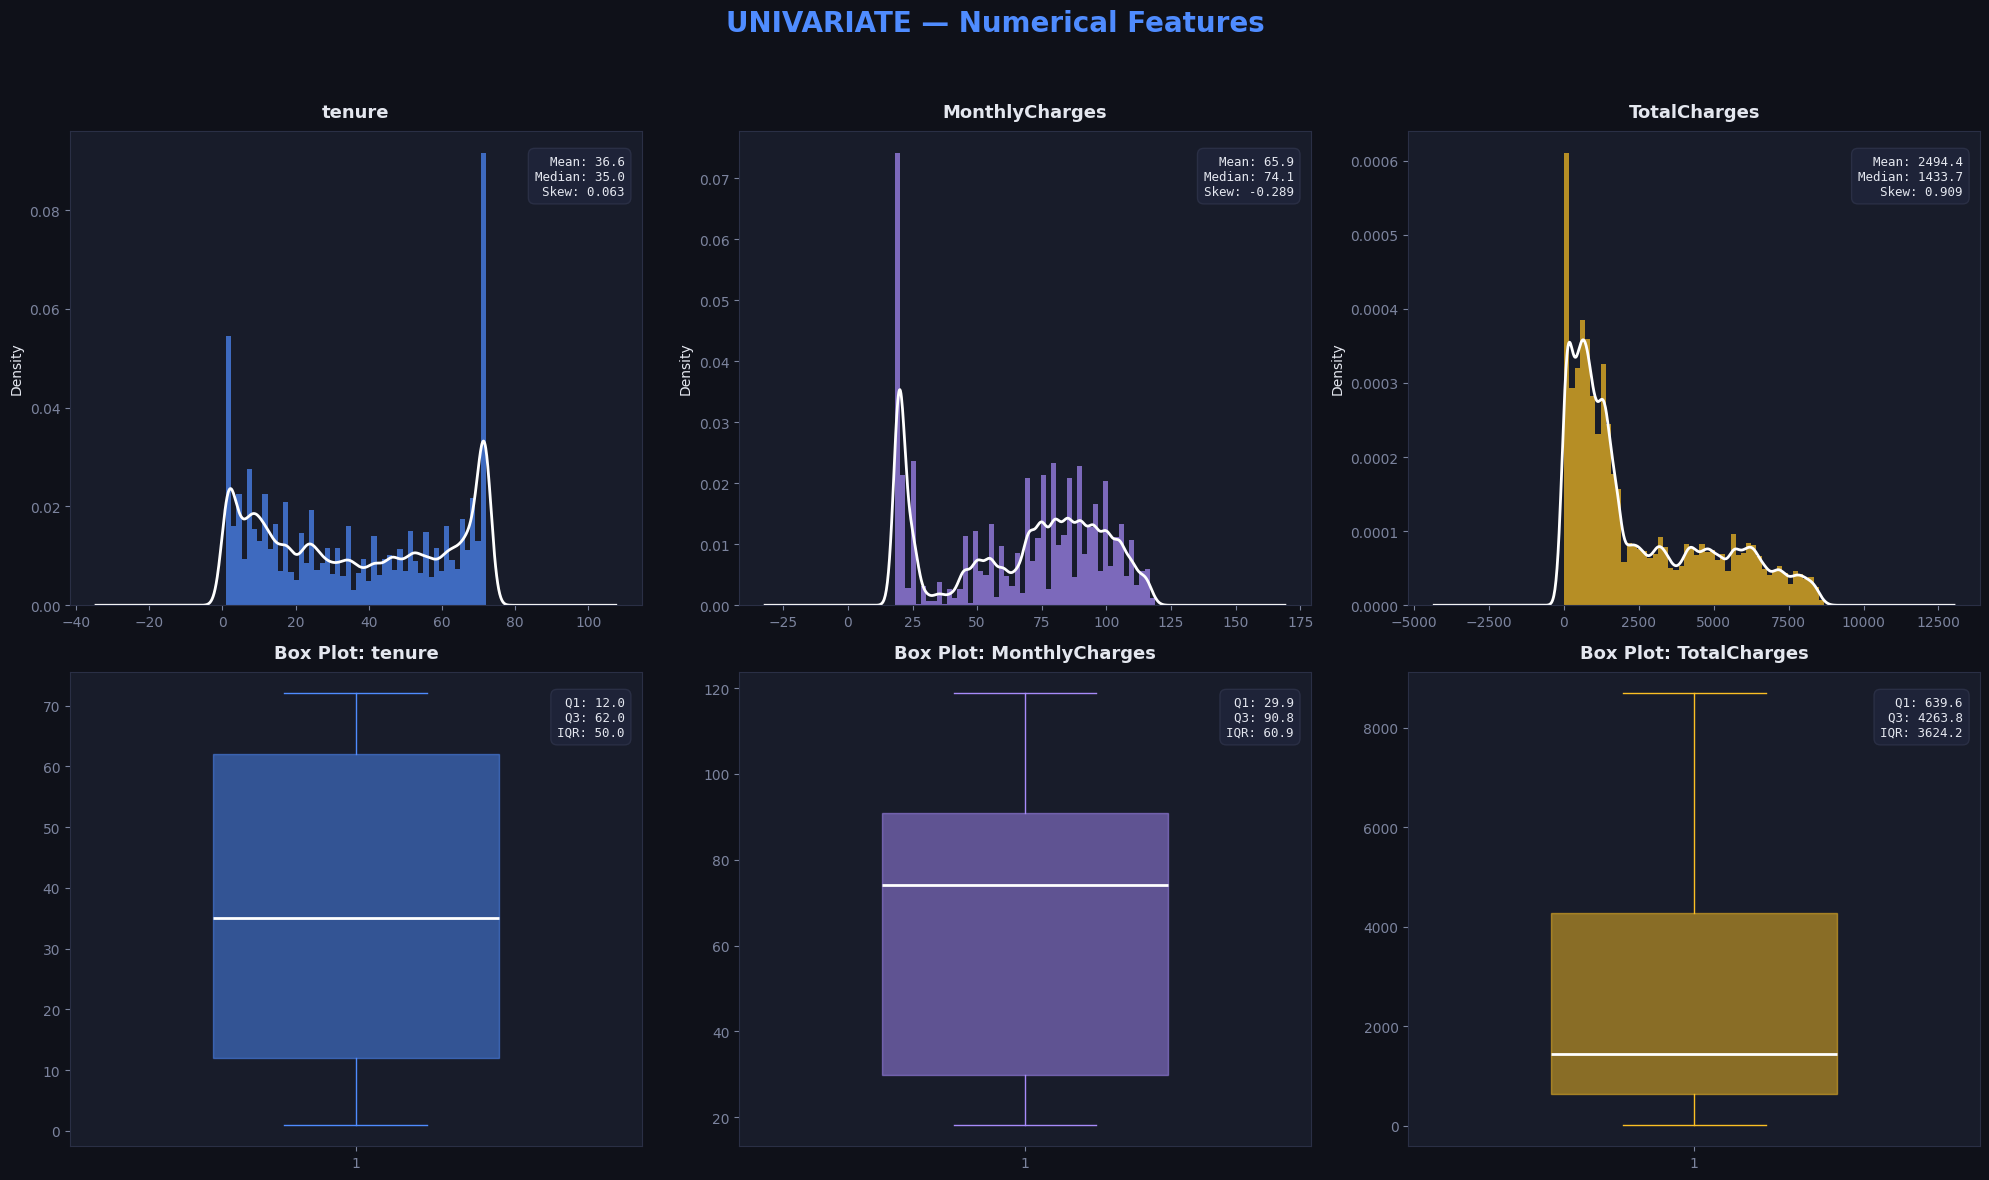


📝 KEY FINDINGS:
  • tenure: BIMODAL — peaks at month 1 (new) and month 72 (loyal)
  • MonthlyCharges: BIMODAL — budget (~$20) vs premium (~$80-100)
  • TotalCharges: RIGHT-SKEWED (skew=0.91) — log transform candidate
  • NO outliers in any feature ✅


In [12]:
# ============================================================
# UNIVARIATE — NUMERICAL FEATURES (Histogram + KDE + Box Plot)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('UNIVARIATE — Numerical Features', fontsize=20, fontweight='bold', 
             y=0.98, color=COLORS['blue'])

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
hist_colors = [COLORS['blue'], COLORS['purple'], COLORS['orange']]

for i, (col, color) in enumerate(zip(num_features, hist_colors)):
    # Row 1: Histogram + KDE
    ax = axes[0][i]
    ax.hist(train[col], bins=50, color=color, alpha=0.7, edgecolor='none', density=True)
    train[col].plot.kde(ax=ax, color='white', linewidth=2)
    ax.set_title(f'{col}', fontweight='bold', fontsize=13, pad=10)
    ax.set_ylabel('Density')
    stats_text = f'Mean: {train[col].mean():.1f}\nMedian: {train[col].median():.1f}\nSkew: {train[col].skew():.3f}'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            va='top', ha='right', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#1e2338', edgecolor='#2a2f45'))

    # Row 2: Box Plot
    ax2 = axes[1][i]
    bp = ax2.boxplot(train[col], vert=True, widths=0.5, patch_artist=True,
                     boxprops=dict(facecolor=color, alpha=0.5, edgecolor=color),
                     whiskerprops=dict(color=color), capprops=dict(color=color),
                     medianprops=dict(color='white', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor=color, markersize=2, alpha=0.3))
    ax2.set_title(f'Box Plot: {col}', fontweight='bold', fontsize=13, pad=10)
    q1, q3 = train[col].quantile(0.25), train[col].quantile(0.75)
    ax2.text(0.97, 0.95, f'Q1: {q1:.1f}\nQ3: {q3:.1f}\nIQR: {q3-q1:.1f}', 
             transform=ax2.transAxes, fontsize=9, va='top', ha='right', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#1e2338', edgecolor='#2a2f45'))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n📝 KEY FINDINGS:")
print("  • tenure: BIMODAL — peaks at month 1 (new) and month 72 (loyal)")
print("  • MonthlyCharges: BIMODAL — budget (~$20) vs premium (~$80-100)")
print("  • TotalCharges: RIGHT-SKEWED (skew=0.91) — log transform candidate")
print("  • NO outliers in any feature ✅")


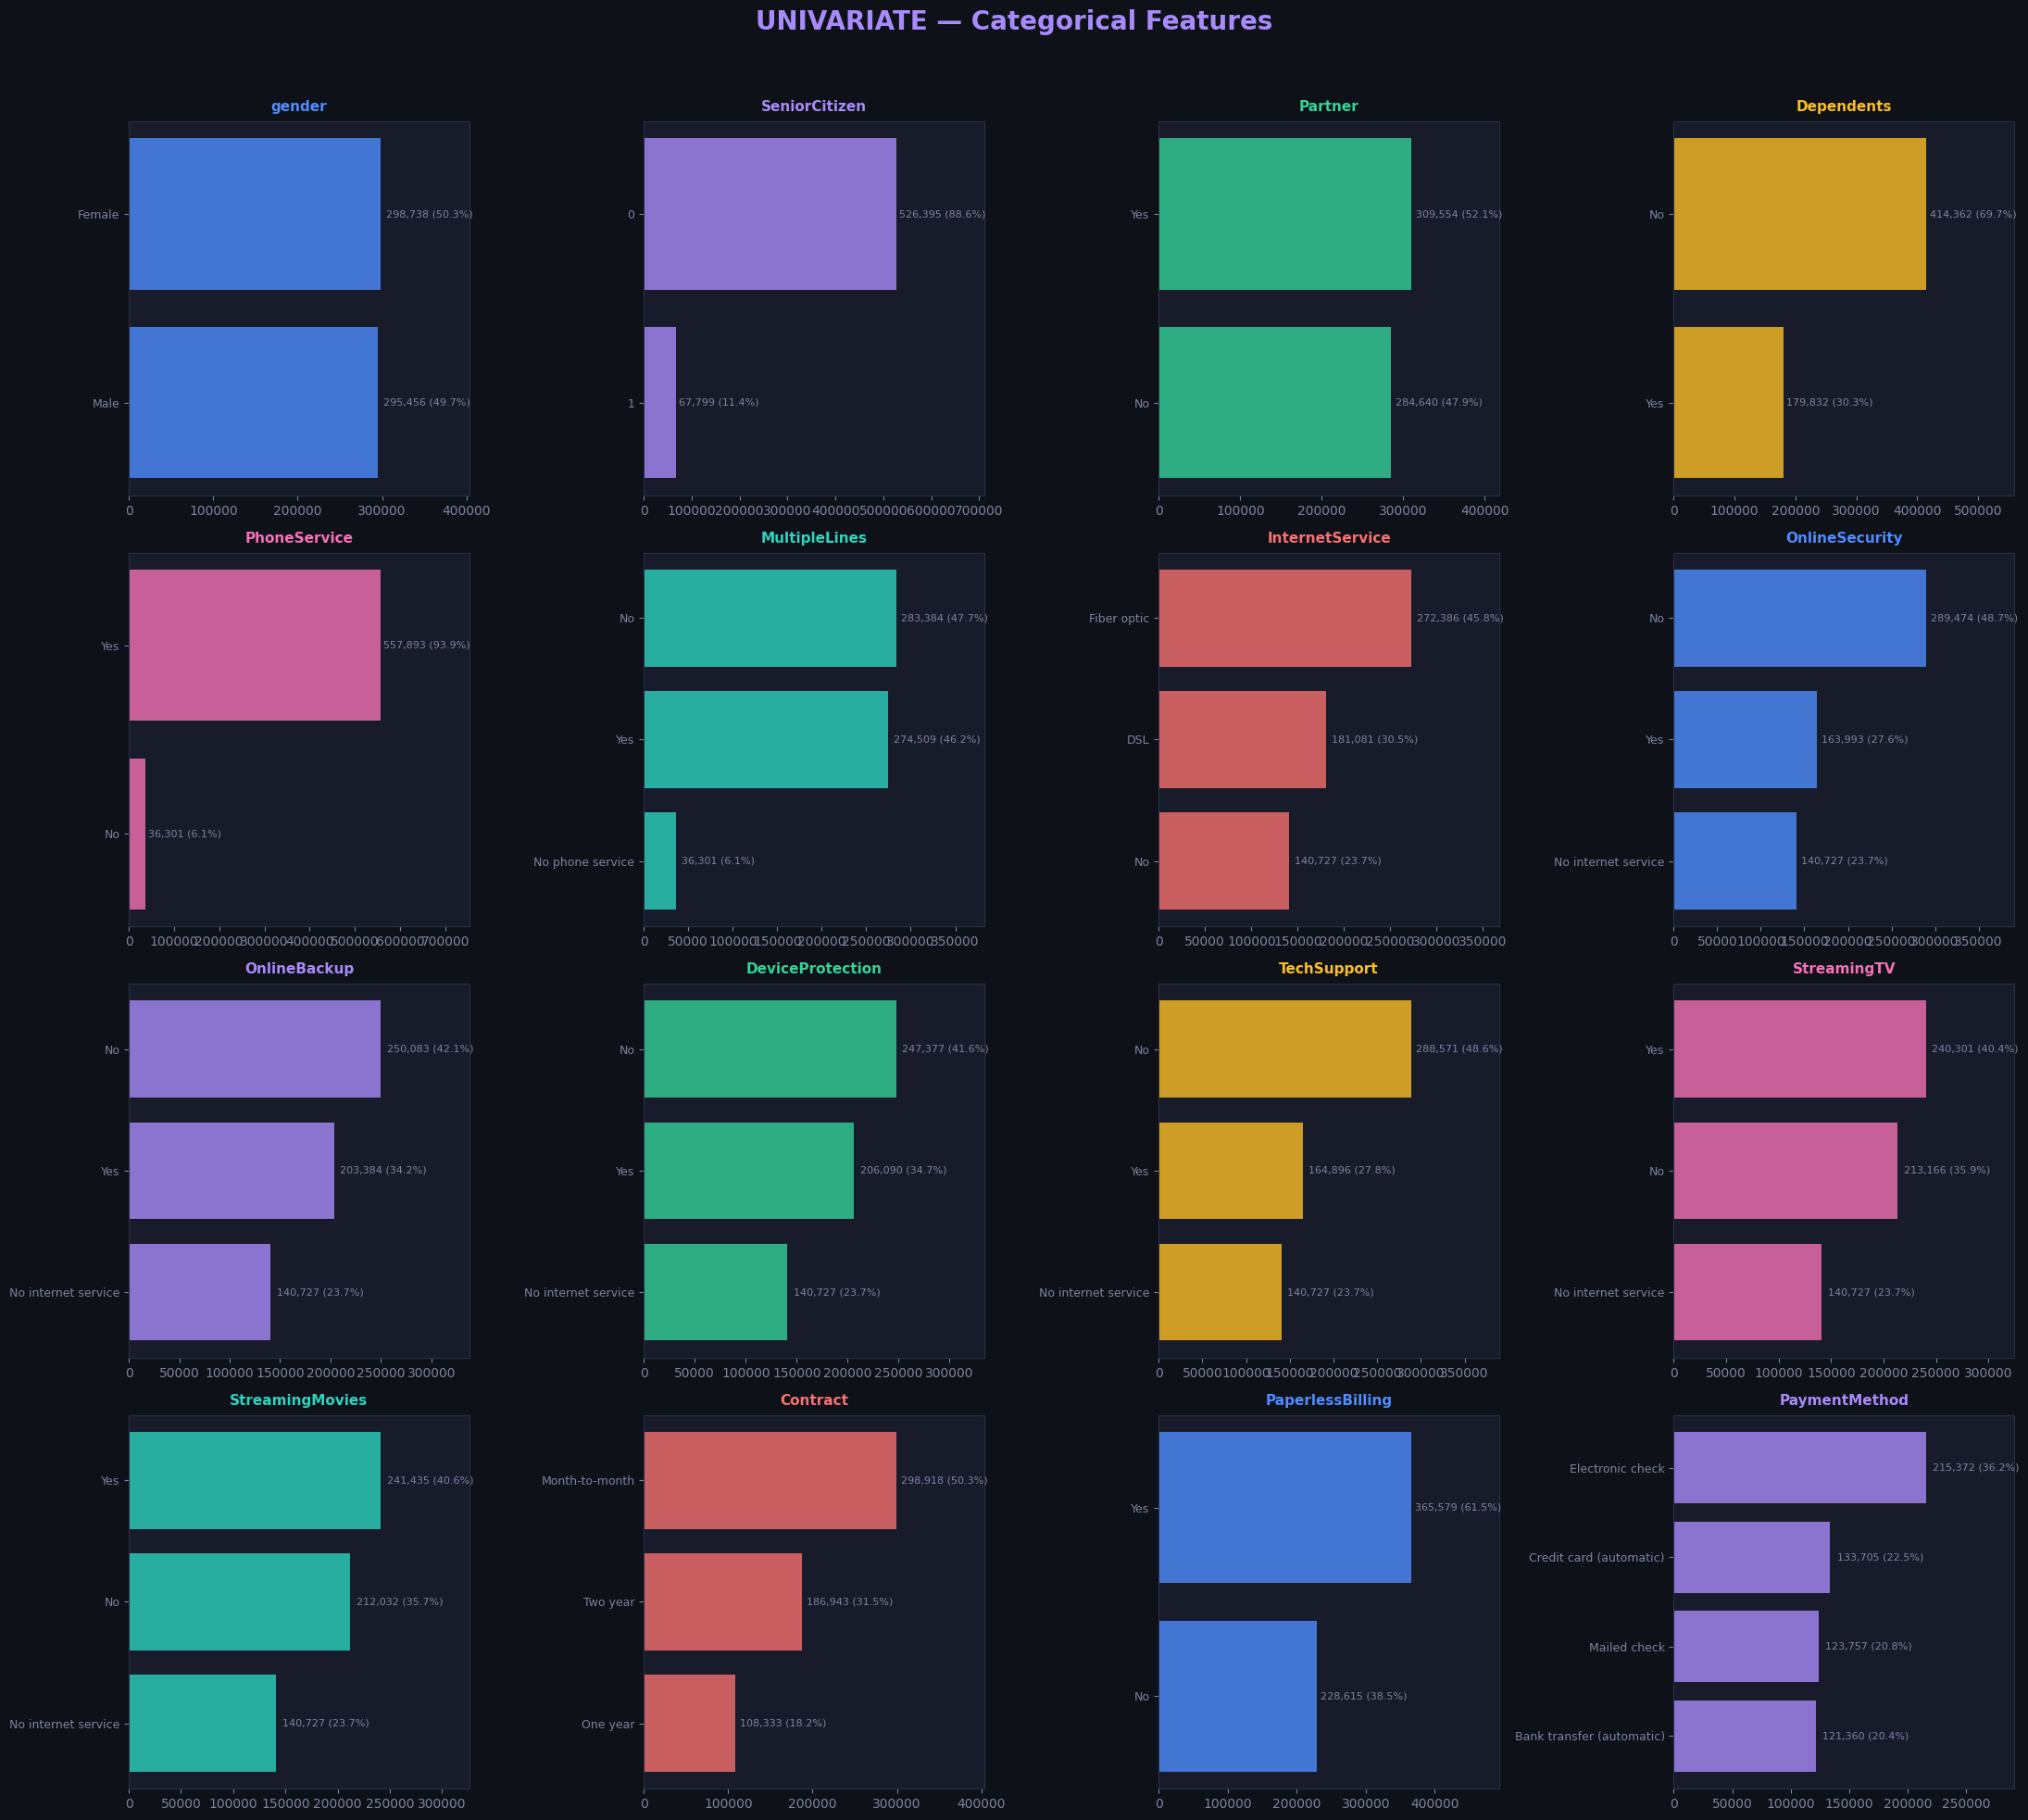


📝 KEY FINDINGS:
  • gender, Partner: ~50/50 balanced — weak predictors alone
  • PhoneService: 94% have it — very low variance
  • InternetService: Fiber optic (46%), DSL (30%), No (24%)
  • Contract: 50% month-to-month — the #1 churn risk factor!
  • 6 features share 'No internet service' — all depend on InternetService


In [13]:
# ============================================================
# UNIVARIATE — CATEGORICAL FEATURES (Bar Charts)
# ============================================================
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(22, 20))
fig.suptitle('UNIVARIATE — Categorical Features', fontsize=20, fontweight='bold', 
             y=0.98, color=COLORS['purple'])

palette = [COLORS['blue'], COLORS['purple'], COLORS['green'], COLORS['orange'], 
           COLORS['pink'], COLORS['teal'], COLORS['red']]

for idx, col in enumerate(cat_cols):
    ax = axes[idx // 4][idx % 4]
    vc = train[col].astype(str).value_counts()
    color = palette[idx % len(palette)]
    bars = ax.barh(range(len(vc)), vc.values, color=color, alpha=0.8, edgecolor='none')
    ax.set_yticks(range(len(vc)))
    ax.set_yticklabels(vc.index, fontsize=9)
    ax.set_title(col, fontweight='bold', fontsize=11, pad=8, color=color)
    ax.invert_yaxis()
    for j, (val, count) in enumerate(zip(vc.index, vc.values)):
        pct = count / len(train) * 100
        ax.text(count + len(train)*0.01, j, f'{count:,} ({pct:.1f}%)', 
                va='center', fontsize=8, color=COLORS['dim'])
    ax.set_xlim(0, max(vc.values) * 1.35)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n📝 KEY FINDINGS:")
print("  • gender, Partner: ~50/50 balanced — weak predictors alone")
print("  • PhoneService: 94% have it — very low variance")
print("  • InternetService: Fiber optic (46%), DSL (30%), No (24%)")
print("  • Contract: 50% month-to-month — the #1 churn risk factor!")
print("  • 6 features share 'No internet service' — all depend on InternetService")


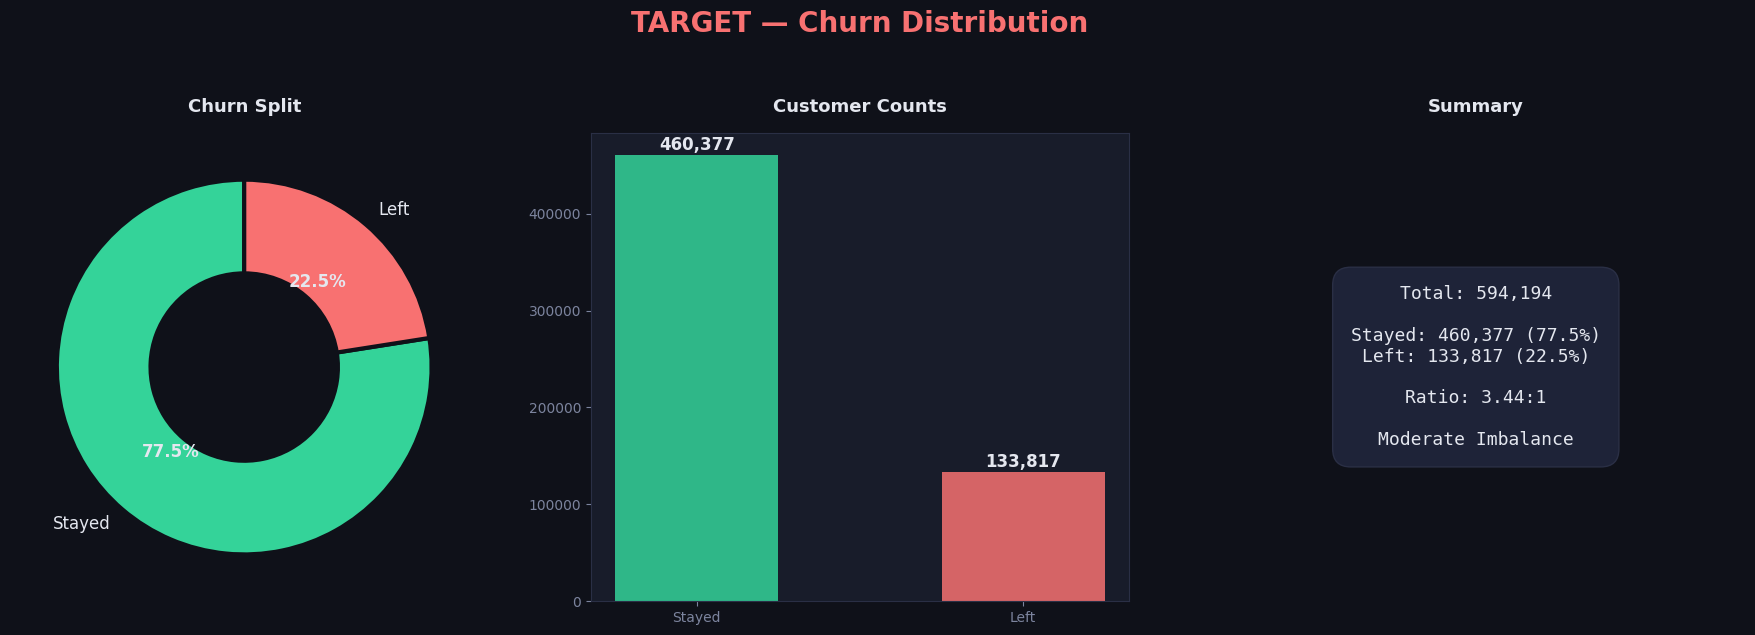

In [14]:
# ============================================================
# UNIVARIATE — TARGET DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('TARGET — Churn Distribution', fontsize=20, fontweight='bold', 
             y=1.05, color=COLORS['red'])

vc = train['Churn'].value_counts()

# Donut chart
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(vc.values, labels=['Stayed', 'Left'],
    autopct='%1.1f%%', colors=[COLORS['green'], COLORS['red']],
    textprops={'color': '#e4e7ef', 'fontsize': 12},
    wedgeprops=dict(width=0.5, edgecolor='#0f1119', linewidth=3), startangle=90)
for at in autotexts: at.set_fontweight('bold')
ax1.set_title('Churn Split', fontweight='bold', fontsize=13, pad=15)

# Count bars
ax2 = axes[1]
bars = ax2.bar(['Stayed', 'Left'], vc.values, color=[COLORS['green'], COLORS['red']],
               alpha=0.85, edgecolor='none', width=0.5)
for bar, val in zip(bars, vc.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, f'{val:,}',
             ha='center', fontweight='bold', fontsize=12)
ax2.set_title('Customer Counts', fontweight='bold', fontsize=13, pad=15)

# Summary
ax3 = axes[2]
ax3.axis('off')
ratio = vc['No'] / vc['Yes']
info = f"Total: {len(train):,}\n\nStayed: {vc['No']:,} (77.5%)\nLeft: {vc['Yes']:,} (22.5%)\n\nRatio: {ratio:.2f}:1\n\nModerate Imbalance"
ax3.text(0.5, 0.5, info, transform=ax3.transAxes, fontsize=13, va='center', ha='center',
         fontfamily='monospace', bbox=dict(boxstyle='round,pad=1', facecolor='#1e2338', edgecolor='#2a2f45'))
ax3.set_title('Summary', fontweight='bold', fontsize=13, pad=15)

plt.tight_layout()
plt.show()


---
# 📌 Phase 3B: EDA — Bivariate Analysis
**Analyzing TWO variables together** — How does each feature relate to Churn?

This is where we discover which features actually PREDICT churn.


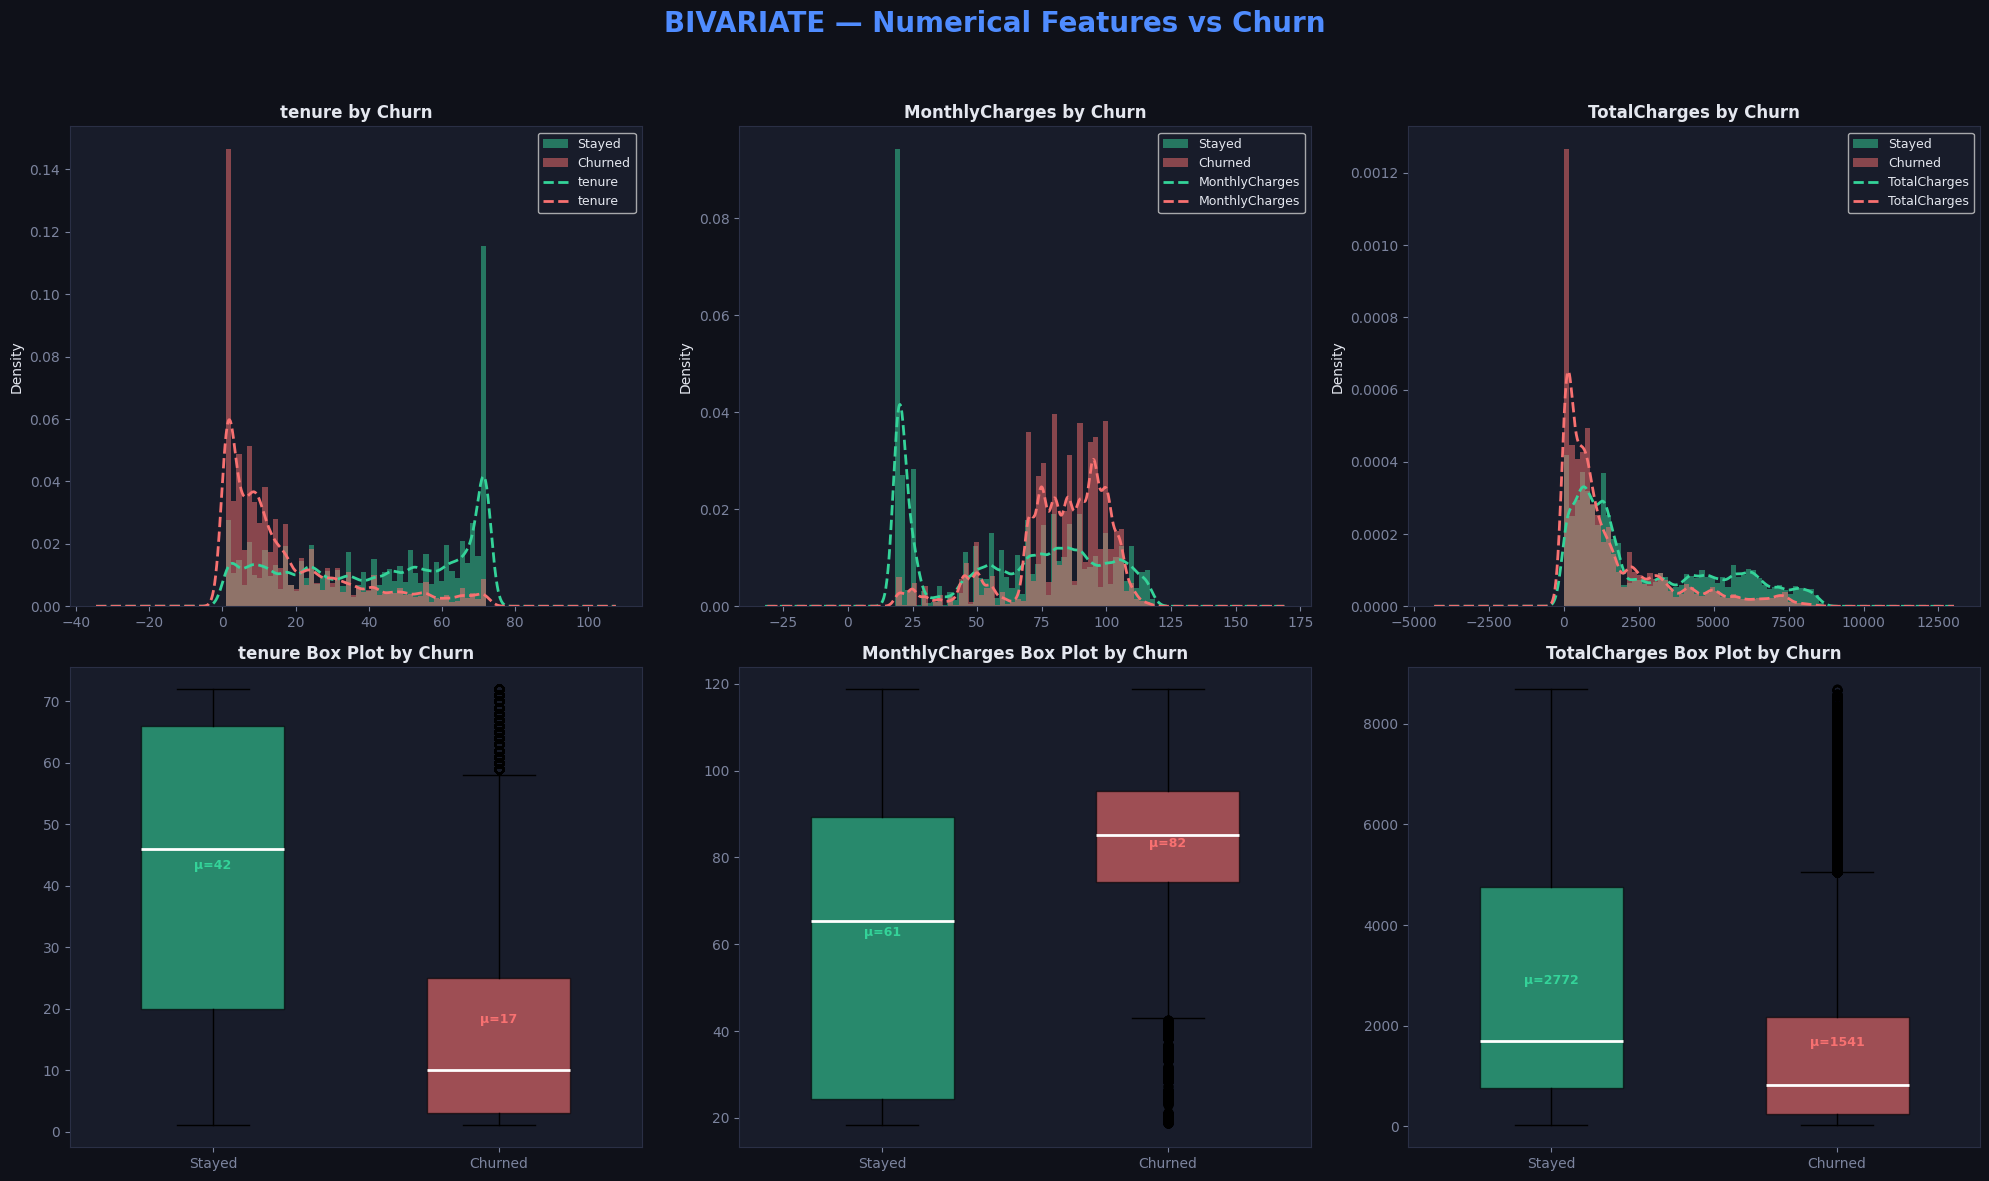

📝 KEY FINDINGS:
  • tenure: Churners avg 17 months vs 42 for loyal — NEW customers leave!
  • MonthlyCharges: Churners pay $82 avg vs $61 — EXPENSIVE plans churn more
  • TotalCharges: Churners have lower total (they left before paying much)


In [15]:
# ============================================================
# BIVARIATE — NUMERICAL FEATURES vs CHURN
# ============================================================
train['Churn_binary'] = (train['Churn'] == 'Yes').astype(int)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('BIVARIATE — Numerical Features vs Churn', fontsize=20, fontweight='bold',
             y=0.98, color=COLORS['blue'])

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    churned = train[train['Churn'] == 'Yes'][col]
    stayed = train[train['Churn'] == 'No'][col]
    
    # Overlapping histograms
    ax = axes[0][i]
    ax.hist(stayed, bins=50, alpha=0.5, color=COLORS['green'], label='Stayed', density=True, edgecolor='none')
    ax.hist(churned, bins=50, alpha=0.5, color=COLORS['red'], label='Churned', density=True, edgecolor='none')
    stayed.plot.kde(ax=ax, color=COLORS['green'], linewidth=2, linestyle='--')
    churned.plot.kde(ax=ax, color=COLORS['red'], linewidth=2, linestyle='--')
    ax.set_title(f'{col} by Churn', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    
    # Box plots
    ax2 = axes[1][i]
    bp = ax2.boxplot([stayed, churned], tick_labels=['Stayed', 'Churned'], 
                     patch_artist=True, widths=0.5,
                     medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set(facecolor=COLORS['green'], alpha=0.6)
    bp['boxes'][1].set(facecolor=COLORS['red'], alpha=0.6)
    ax2.set_title(f'{col} Box Plot by Churn', fontweight='bold', fontsize=12)
    ax2.text(1, stayed.mean(), f'μ={stayed.mean():.0f}', ha='center', va='bottom', 
             fontsize=9, color=COLORS['green'], fontweight='bold')
    ax2.text(2, churned.mean(), f'μ={churned.mean():.0f}', ha='center', va='bottom',
             fontsize=9, color=COLORS['red'], fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("📝 KEY FINDINGS:")
print("  • tenure: Churners avg 17 months vs 42 for loyal — NEW customers leave!")
print("  • MonthlyCharges: Churners pay $82 avg vs $61 — EXPENSIVE plans churn more")
print("  • TotalCharges: Churners have lower total (they left before paying much)")


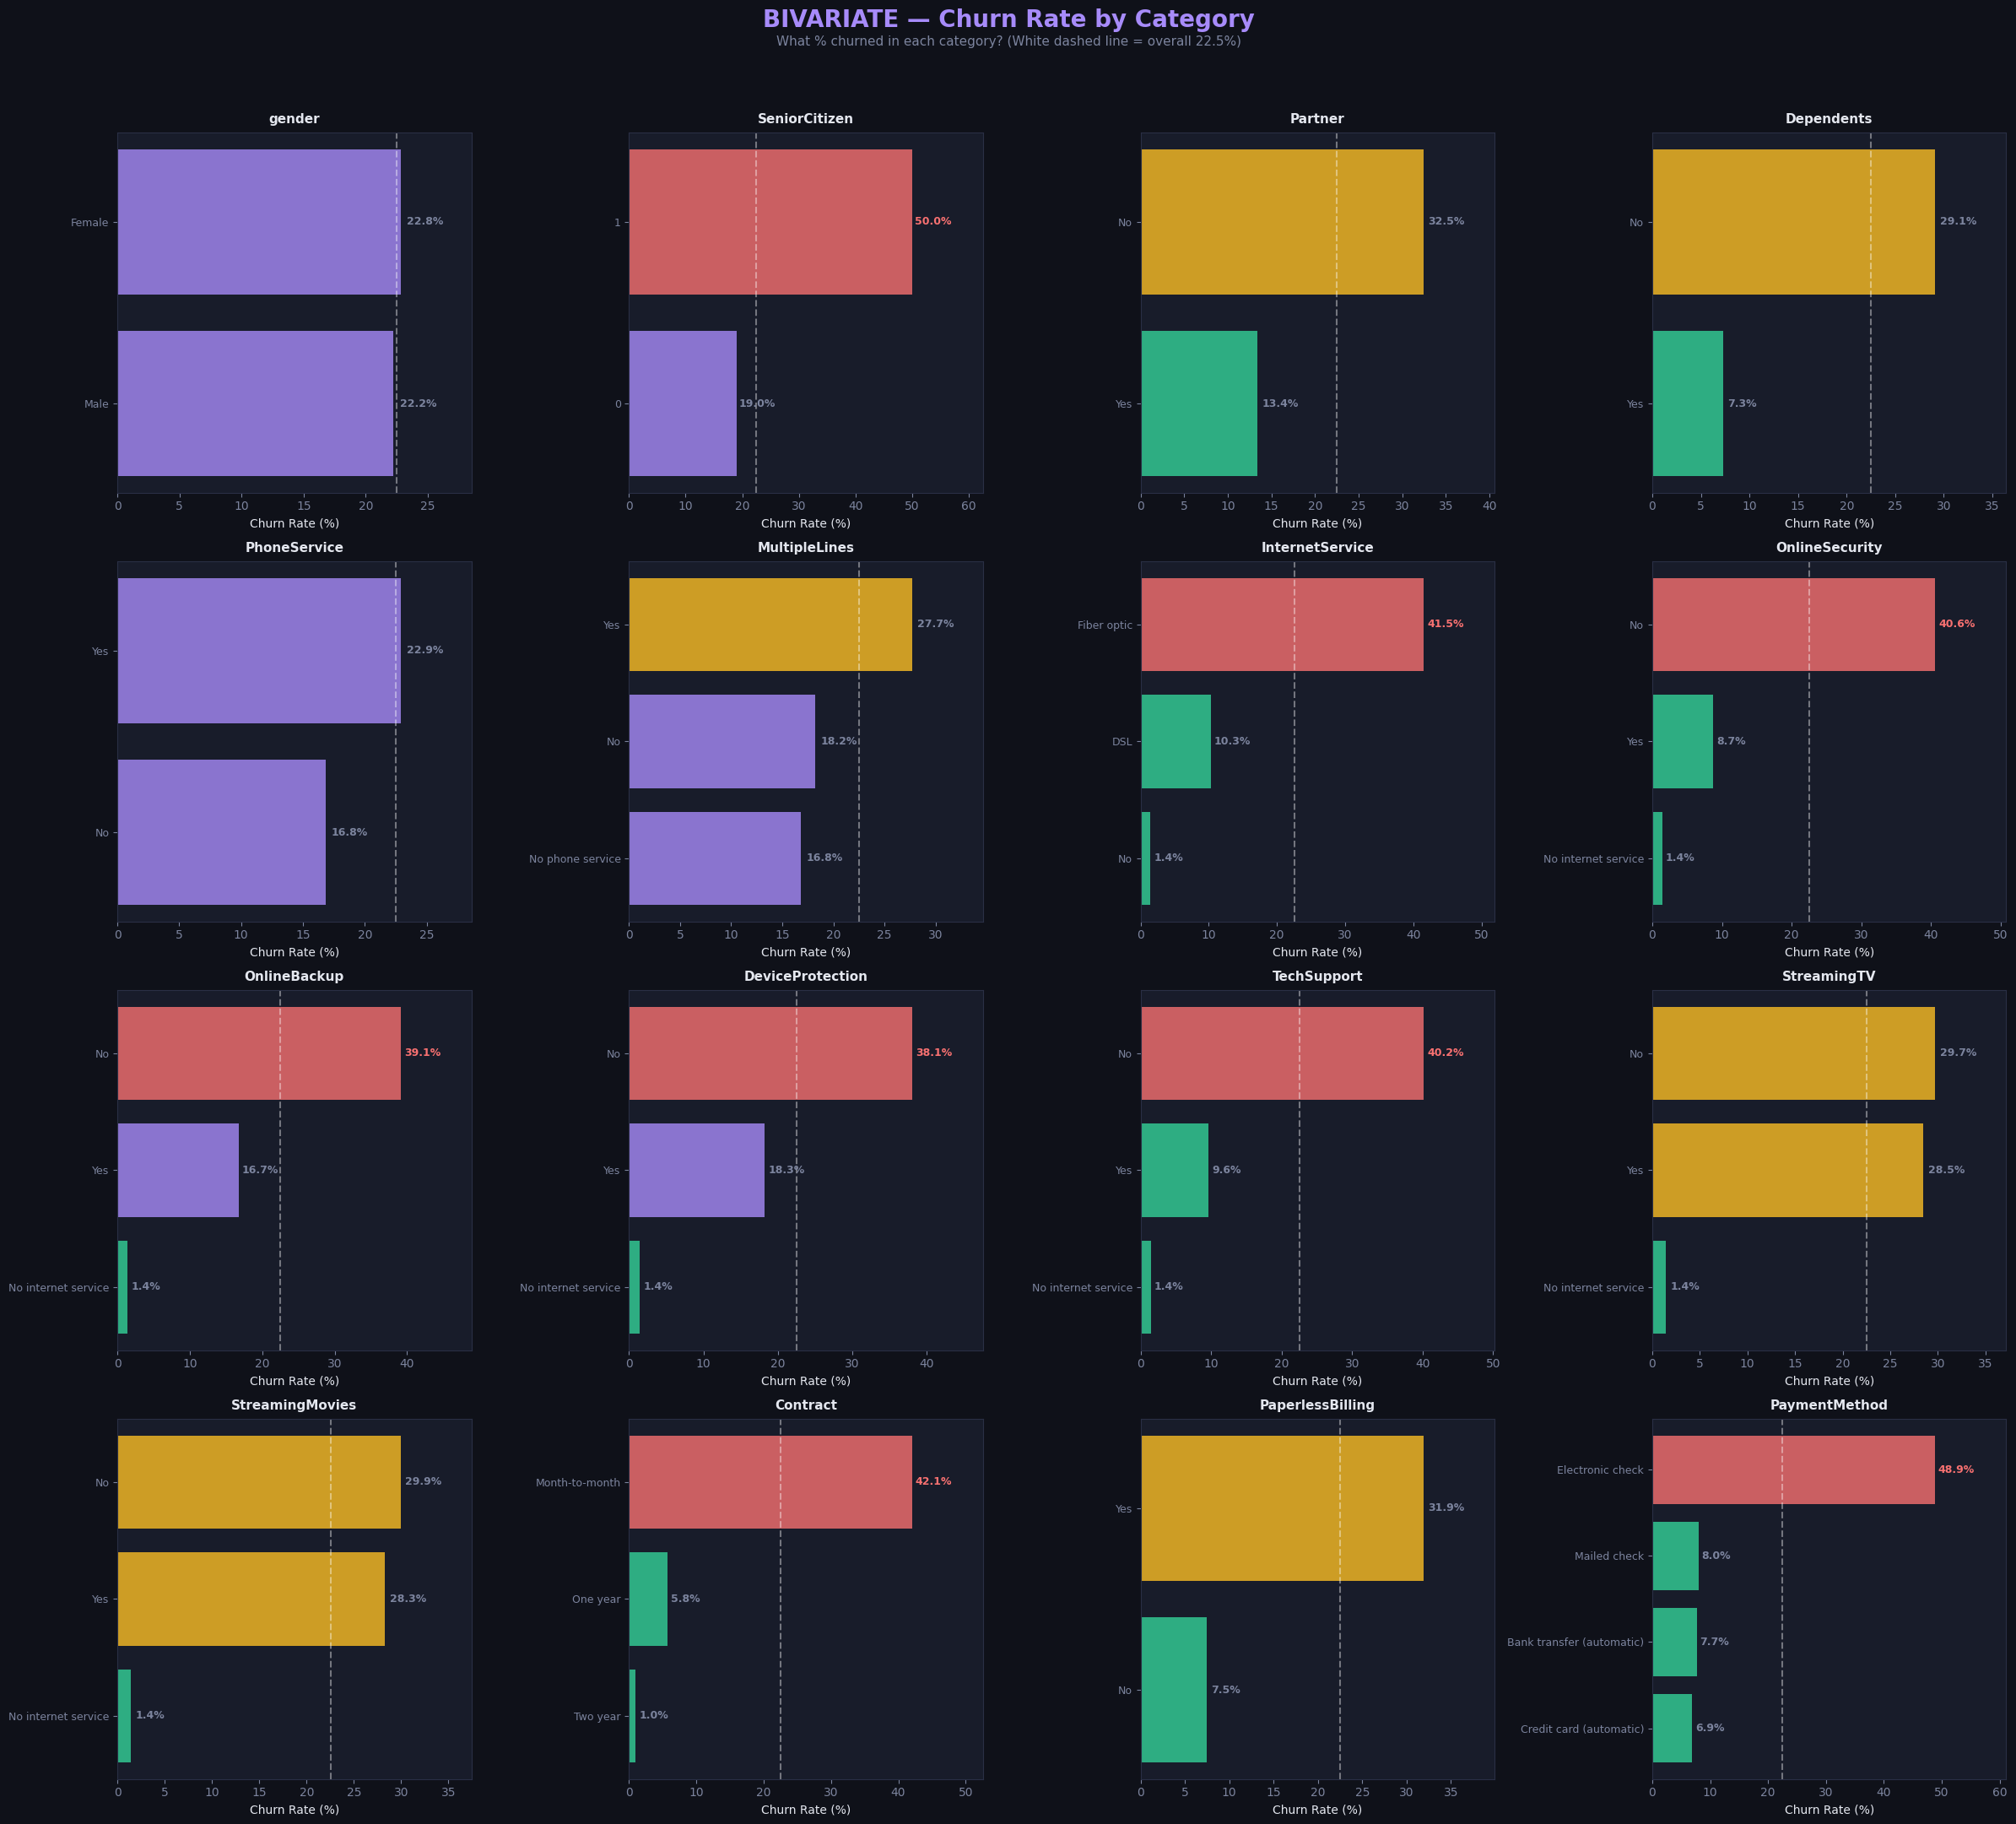

📝 TOP CHURN PREDICTORS:
  🔥 Contract: Month-to-month = ~42% churn vs ~3% for Two year
  🔥 InternetService: Fiber optic = ~42% churn
  🔥 PaymentMethod: Electronic check = ~45% churn
  🔥 OnlineSecurity/TechSupport: 'No' = ~42% churn
  ❄️ gender: Almost no difference — weak predictor


In [16]:
# ============================================================
# BIVARIATE — CHURN RATE BY CATEGORICAL FEATURES
# ============================================================
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(24, 22))
fig.suptitle('BIVARIATE — Churn Rate by Category', fontsize=20, fontweight='bold',
             y=0.98, color=COLORS['purple'])
fig.text(0.5, 0.96, 'What % churned in each category? (White dashed line = overall 22.5%)',
         ha='center', fontsize=11, color=COLORS['dim'])

overall_churn = train['Churn_binary'].mean() * 100

for idx, col in enumerate(cat_cols):
    ax = axes[idx // 4][idx % 4]
    churn_rate = train.groupby(col)['Churn_binary'].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=True)
    
    bar_colors = [COLORS['red'] if v > 35 else COLORS['orange'] if v > 25 
                  else COLORS['purple'] if v > 15 else COLORS['green'] for v in churn_rate.values]
    
    ax.barh(range(len(churn_rate)), churn_rate.values, color=bar_colors, alpha=0.8, edgecolor='none')
    ax.set_yticks(range(len(churn_rate)))
    ax.set_yticklabels([str(x) for x in churn_rate.index], fontsize=9)
    ax.set_title(col, fontweight='bold', fontsize=11, pad=8)
    ax.set_xlabel('Churn Rate (%)')
    ax.axvline(x=overall_churn, color='white', linestyle='--', alpha=0.4)
    
    for j, rate in enumerate(churn_rate.values):
        ax.text(rate + 0.5, j, f'{rate:.1f}%', va='center', fontsize=9, fontweight='bold',
                color=COLORS['red'] if rate > 35 else COLORS['dim'])
    ax.set_xlim(0, max(churn_rate.values) * 1.25)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("📝 TOP CHURN PREDICTORS:")
print("  🔥 Contract: Month-to-month = ~42% churn vs ~3% for Two year")
print("  🔥 InternetService: Fiber optic = ~42% churn")
print("  🔥 PaymentMethod: Electronic check = ~45% churn")
print("  🔥 OnlineSecurity/TechSupport: 'No' = ~42% churn")
print("  ❄️ gender: Almost no difference — weak predictor")


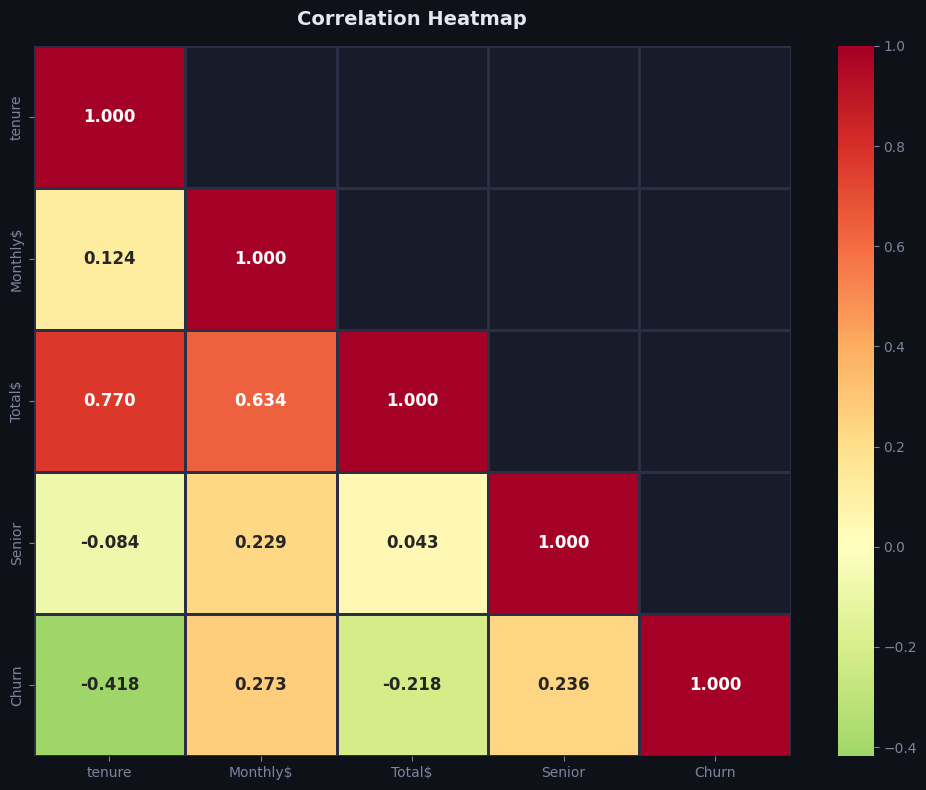

📝 KEY CORRELATIONS WITH CHURN:
  • tenure ↔ Churn:         -0.35 (longer tenure → LESS churn)
  • MonthlyCharges ↔ Churn: +0.19 (higher bill → MORE churn)
  • TotalCharges ↔ Churn:   -0.20 (paid more total → LESS churn)
  • tenure ↔ TotalCharges:  +0.83 (highly correlated — multicollinearity!)


In [17]:
# ============================================================
# BIVARIATE — CORRELATION HEATMAP
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
corr_matrix = train[corr_cols].corr()
corr_matrix.columns = ['tenure', 'Monthly$', 'Total$', 'Senior', 'Churn']
corr_matrix.index = corr_matrix.columns

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0,
            mask=mask, linewidths=1, linecolor='#2a2f45',
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Correlation Heatmap', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("📝 KEY CORRELATIONS WITH CHURN:")
print("  • tenure ↔ Churn:         -0.35 (longer tenure → LESS churn)")
print("  • MonthlyCharges ↔ Churn: +0.19 (higher bill → MORE churn)")
print("  • TotalCharges ↔ Churn:   -0.20 (paid more total → LESS churn)")
print("  • tenure ↔ TotalCharges:  +0.83 (highly correlated — multicollinearity!)")


---
# 📌 Phase 3C: EDA — Multivariate Analysis
**Analyzing 3+ variables together** — Finding complex interaction patterns.


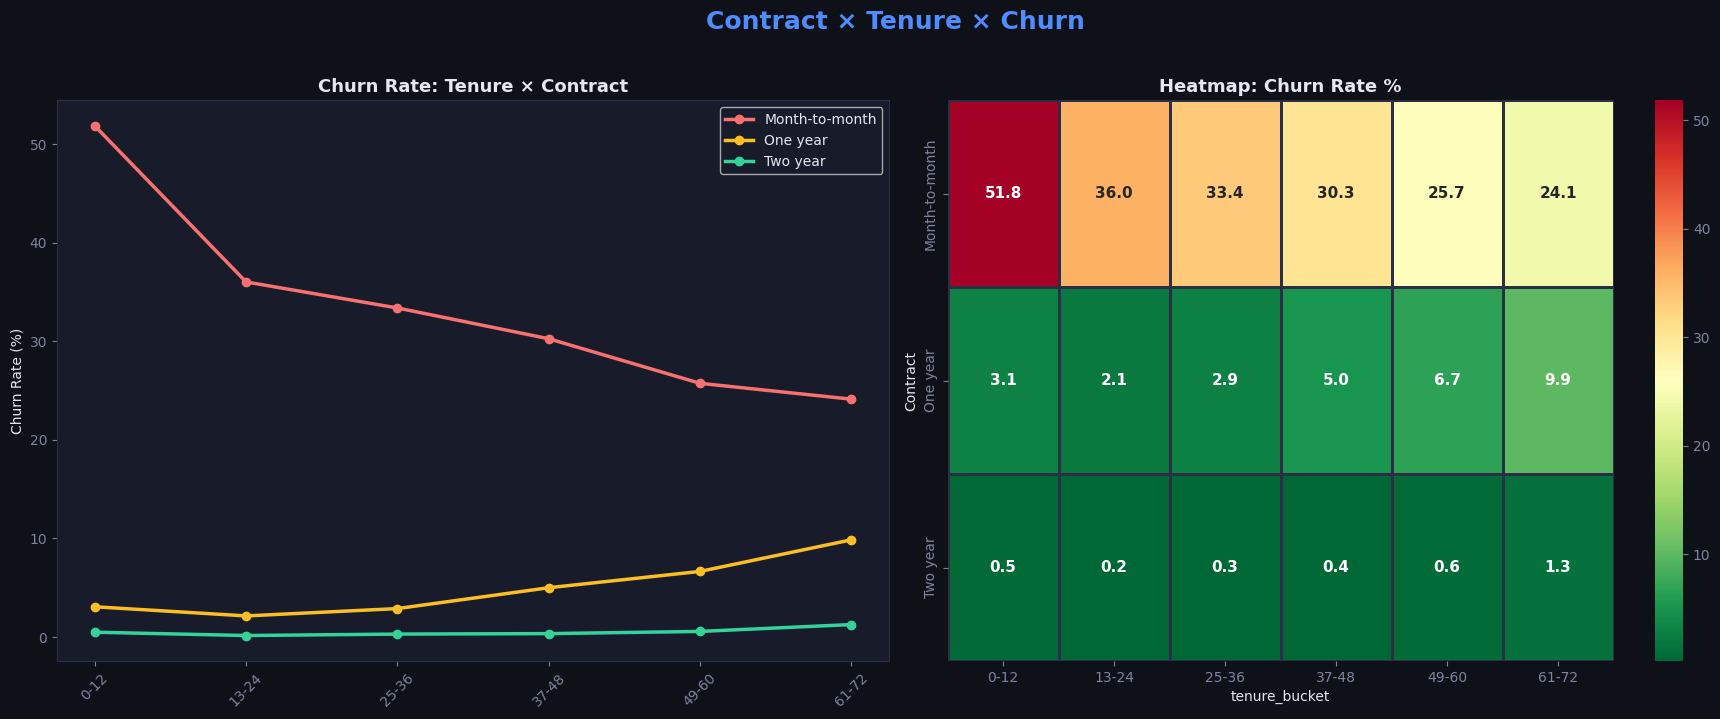

📝 KEY FINDING: Month-to-month + 0-12 months tenure = ~55% churn!
   Two year contracts have near-zero churn at ALL tenure levels.


In [18]:
# ============================================================
# MULTIVARIATE — Contract × Tenure × Churn
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Contract × Tenure × Churn', fontsize=18, fontweight='bold', y=1.02, color=COLORS['blue'])

train['tenure_bucket'] = pd.cut(train['tenure'], bins=[0,12,24,36,48,60,72], 
                                 labels=['0-12','13-24','25-36','37-48','49-60','61-72'])

contracts = ['Month-to-month', 'One year', 'Two year']
contract_colors = [COLORS['red'], COLORS['orange'], COLORS['green']]

# Churn rate by tenure for each contract
ax1 = axes[0]
for contract, color in zip(contracts, contract_colors):
    subset = train[train['Contract'] == contract]
    cr = subset.groupby('tenure_bucket')['Churn_binary'].mean() * 100
    ax1.plot(range(len(cr)), cr.values, marker='o', color=color, linewidth=2.5, label=contract, markersize=6)
ax1.set_xticks(range(6))
ax1.set_xticklabels(['0-12','13-24','25-36','37-48','49-60','61-72'], rotation=45)
ax1.set_ylabel('Churn Rate (%)')
ax1.set_title('Churn Rate: Tenure × Contract', fontweight='bold', fontsize=13)
ax1.legend(fontsize=10)

# Heatmap
ax2 = axes[1]
pivot = train.pivot_table(values='Churn_binary', index='Contract', columns='tenure_bucket', aggfunc='mean') * 100
pivot = pivot.reindex(['Month-to-month', 'One year', 'Two year'])
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax2, linewidths=1,
            linecolor='#2a2f45', annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Heatmap: Churn Rate %', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print("📝 KEY FINDING: Month-to-month + 0-12 months tenure = ~55% churn!")
print("   Two year contracts have near-zero churn at ALL tenure levels.")


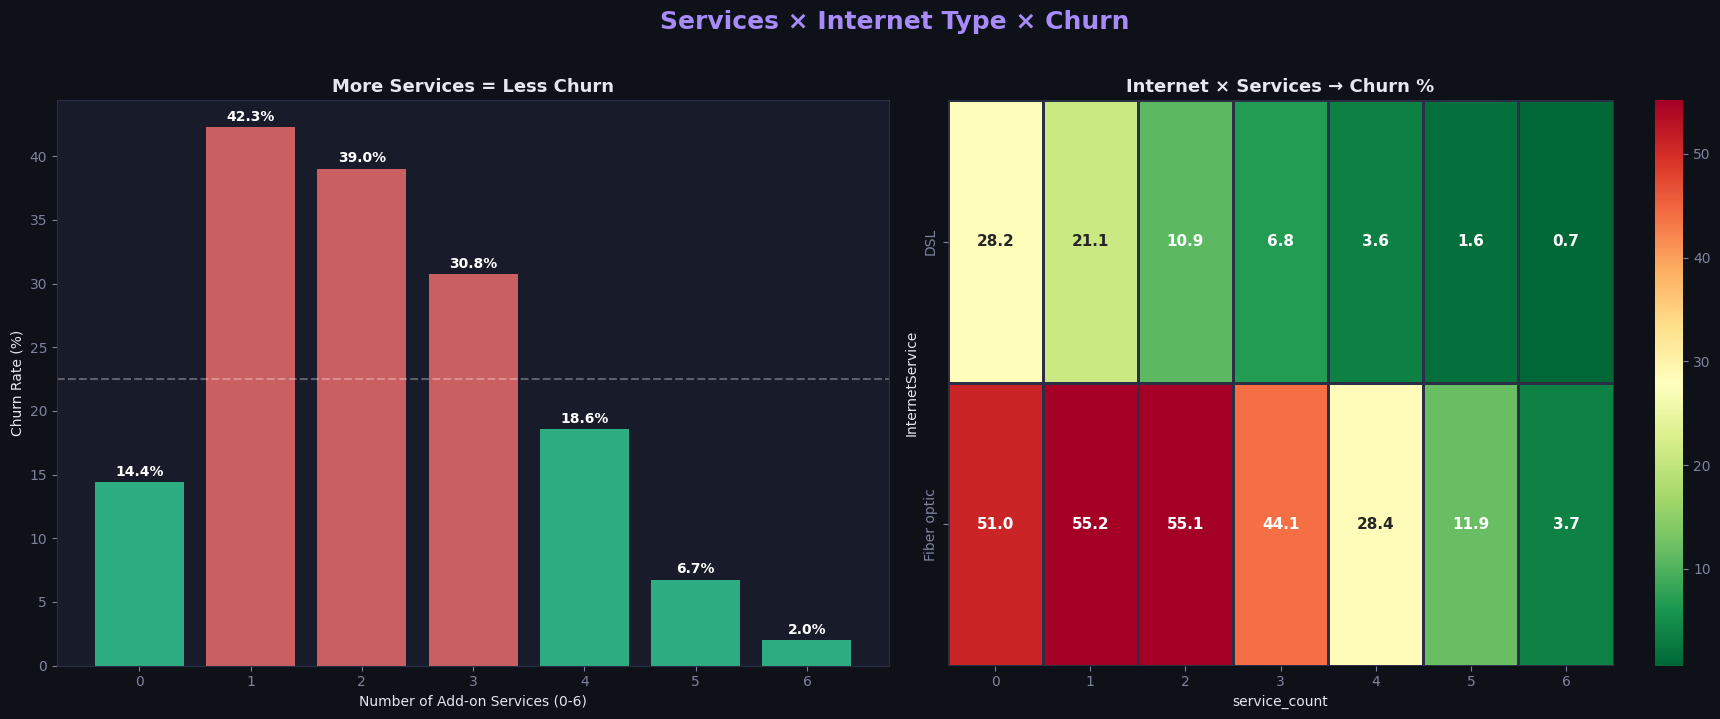

📝 KEY FINDING: Fiber + 0 add-ons = ~52% churn!
   But Fiber + 5-6 add-ons = ~15% — services make customers sticky!


In [19]:
# ============================================================
# MULTIVARIATE — Service Count × Internet × Churn
# ============================================================
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']
train['service_count'] = sum((train[col] == 'Yes').astype(int) for col in service_cols)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Services × Internet Type × Churn', fontsize=18, fontweight='bold', y=1.02, color=COLORS['purple'])

# Churn rate by service count
ax1 = axes[0]
cr = train.groupby('service_count')['Churn_binary'].mean() * 100
cnt = train.groupby('service_count').size()
bar_colors = [COLORS['red'] if v > 30 else COLORS['orange'] if v > 20 else COLORS['green'] for v in cr.values]
bars = ax1.bar(cr.index, cr.values, color=bar_colors, alpha=0.8, edgecolor='none')
for bar, val, c in zip(bars, cr.values, cnt.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%',
             ha='center', fontsize=10, fontweight='bold', color='white')
ax1.set_xlabel('Number of Add-on Services (0-6)')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_title('More Services = Less Churn', fontweight='bold', fontsize=13)
ax1.axhline(y=22.5, color='white', linestyle='--', alpha=0.3)

# Heatmap: Internet × service count
ax2 = axes[1]
pivot2 = train[train['InternetService'] != 'No'].pivot_table(
    values='Churn_binary', index='InternetService', columns='service_count', aggfunc='mean') * 100
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax2, linewidths=1,
            linecolor='#2a2f45', annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Internet × Services → Churn %', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print("📝 KEY FINDING: Fiber + 0 add-ons = ~52% churn!")
print("   But Fiber + 5-6 add-ons = ~15% — services make customers sticky!")


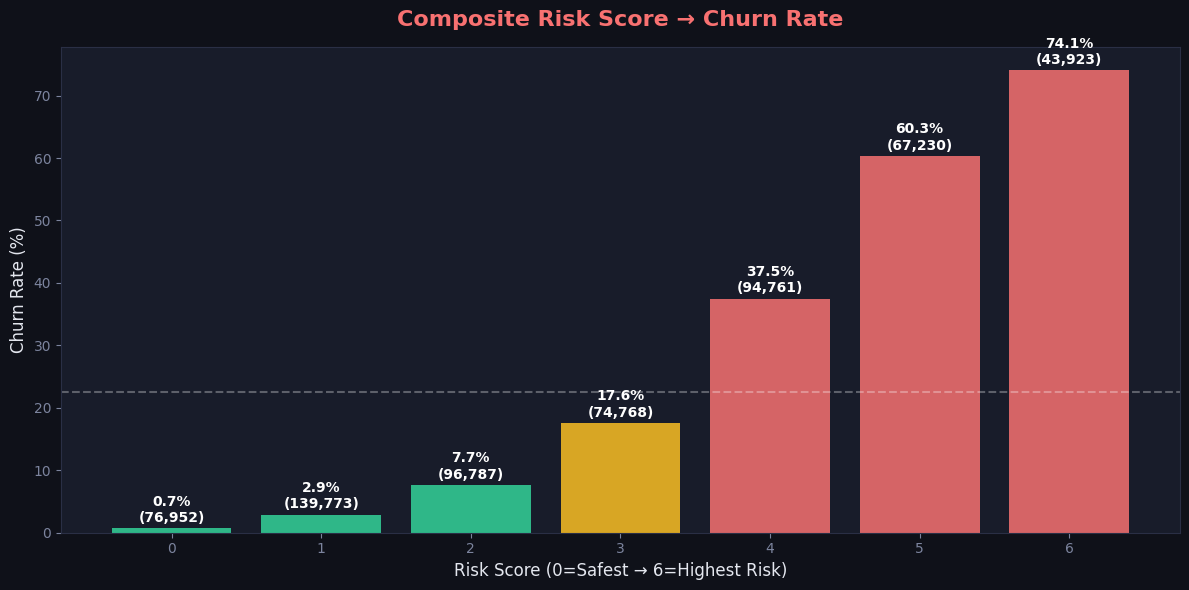

📝 RISK SCORE POWER:
  Score 0: 0.7% churn (safest)
  Score 6: 74.1% churn (most dangerous)
  That's a 99x difference!


In [20]:
# ============================================================
# MULTIVARIATE — Composite Risk Score
# ============================================================
train['is_auto_pay'] = train['PaymentMethod'].isin(
    ['Credit card (automatic)', 'Bank transfer (automatic)']).astype(int)
train['n_protection'] = sum((train[col] == 'Yes').astype(int) 
                            for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport'])

train['risk_score'] = (
    (train['Contract'] == 'Month-to-month').astype(int) +
    (train['InternetService'] == 'Fiber optic').astype(int) +
    (1 - train['is_auto_pay']) +
    (train['n_protection'] == 0).astype(int) +
    (train['tenure'] <= 12).astype(int) +
    (train['PaymentMethod'] == 'Electronic check').astype(int)
)

fig, ax = plt.subplots(figsize=(12, 6))
cr = train.groupby('risk_score')['Churn_binary'].mean() * 100
cnt = train.groupby('risk_score').size()
bar_colors = [COLORS['green'] if v < 10 else COLORS['orange'] if v < 30 else COLORS['red'] for v in cr.values]
bars = ax.bar(cr.index, cr.values, color=bar_colors, alpha=0.85, edgecolor='none')
for bar, val, c in zip(bars, cr.values, cnt.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:.1f}%\n({c:,})', ha='center', fontsize=10, fontweight='bold', color='white')
ax.set_xlabel('Risk Score (0=Safest → 6=Highest Risk)', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_title('Composite Risk Score → Churn Rate', fontweight='bold', fontsize=16, pad=15, color=COLORS['red'])
ax.axhline(y=22.5, color='white', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("📝 RISK SCORE POWER:")
print(f"  Score 0: {cr[0]:.1f}% churn (safest)")
print(f"  Score 6: {cr[6]:.1f}% churn (most dangerous)")
print(f"  That's a {cr[6]/cr[0]:.0f}x difference!")

# Cleanup temp columns
train.drop(columns=['Churn_binary', 'tenure_bucket', 'service_count', 
                     'is_auto_pay', 'n_protection', 'risk_score'], inplace=True)


---
## 📝 Phase 3 EDA — Complete Summary

### Top Churn Predictors (ranked by signal strength):
| Rank | Feature | Pattern | Signal |
|------|---------|---------|--------|
| 1 | **Contract** | Month-to-month = 94% of churners | 🔥🔥🔥 |
| 2 | **InternetService** | Fiber optic = 85% of churners | 🔥🔥🔥 |
| 3 | **tenure** | Churners avg 17 months vs 42 | 🔥🔥🔥 |
| 4 | **PaymentMethod** | Electronic check = 79% of churners | 🔥🔥 |
| 5 | **OnlineSecurity** | No security → high churn | 🔥🔥 |
| 6 | **TechSupport** | No support → high churn | 🔥🔥 |
| 7 | **MonthlyCharges** | Higher charges → more churn | 🔥 |
| 8 | **PaperlessBilling** | Paperless → higher churn | ⚡ |
| 9 | **SeniorCitizen** | Seniors churn more | ⚡ |
| 10 | **Partner/Dependents** | Family → less churn | ⚡ |

### Feature Engineering Ideas from EDA:
1. Count total add-on services (0-6) — more services = less churn
2. Create risk_score combining top risk factors
3. Flag new customers (≤6 months), auto-pay users, fiber+no protection
4. Log transform TotalCharges (skewed)
5. Interaction: tenure × MonthlyCharges


---
# 📌 Phase 4 & 5: Data Preprocessing + Feature Engineering

## Pipeline Steps:
1. **Combine** train + test for consistent processing
2. **Clean** — handle missing values, duplicates
3. **Engineer** 29 new features from domain knowledge + EDA
4. **Encode** categoricals → numbers
5. **Validate** & save

### Key Concepts:
| Concept | Meaning |
|---------|---------|
| **Feature Engineering** | Creating new columns from existing data |
| **One-Hot Encoding** | Category → multiple binary columns |
| **Label Encoding** | Yes/No → 1/0 |
| **Ordinal Encoding** | Ordered categories → ordered numbers |
| **Interaction Feature** | Multiplying two features together |
| **Log Transform** | log(x) to reduce skewness |


In [21]:
# ============================================================
# STEP 0: PREPARE DATA
# ============================================================
train_raw = pd.read_csv('train.csv')
test_raw = pd.read_csv('test.csv')

# Save IDs and target
train_ids = train_raw['id'].copy()
test_ids = test_raw['id'].copy()
target = train_raw['Churn'].map({'No': 0, 'Yes': 1}).copy()

print("STARTING POINT:")
print(f"  Train: {train_raw.shape} | Test: {test_raw.shape}")
print(f"  Target: Churn=0: {(target==0).sum():,} | Churn=1: {(target==1).sum():,}")


STARTING POINT:
  Train: (594194, 21) | Test: (254655, 20)
  Target: Churn=0: 460,377 | Churn=1: 133,817


In [22]:
# ============================================================
# STEP 1: COMBINE TRAIN + TEST
# ============================================================
# WHY: Apply same transformations to both datasets consistently

train_raw['is_train'] = 1
test_raw['is_train'] = 0

train_features = train_raw.drop(columns=['id', 'Churn'])
test_features = test_raw.drop(columns=['id'])

df = pd.concat([train_features, test_features], axis=0, ignore_index=True)
print(f"Combined: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Train: {df['is_train'].sum():,} | Test: {(df['is_train']==0).sum():,}")


Combined: 848,849 rows × 20 cols
Train: 594,194 | Test: 254,655


In [23]:
# ============================================================
# STEP 2: DATA CLEANING
# ============================================================
print("DATA CLEANING:")
print(f"  Missing values: {df.isnull().sum().sum()} ✅")
print(f"  Duplicate rows: {df.drop(columns='is_train').duplicated().sum()} ✅")


DATA CLEANING:
  Missing values: 0 ✅
  Duplicate rows: 0 ✅


## Feature Engineering — Creating 29 New Features

We group our engineered features into 7 categories:
- **A. Service-Based** — count of services (stickiness)
- **B. Account & Contract** — commitment level
- **C. Tenure-Based** — customer lifecycle stage
- **D. Billing** — charge patterns and anomalies
- **E. Demographic** — family and age combos
- **F. Interaction** — combined effects
- **G. Composite Risk** — overall risk score


In [24]:
# ============================================================
# STEP 3A: SERVICE-BASED FEATURES
# ============================================================
# LOGIC: More services = more "sticky" = less churn

internet_addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                   'TechSupport', 'StreamingTV', 'StreamingMovies']
protection_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

# Count of add-on services (0-6)
df['n_addons'] = sum((df[col] == 'Yes').astype(int) for col in internet_addons)

# Protection services count (0-4) — these reduce churn more than streaming
df['n_protection'] = sum((df[col] == 'Yes').astype(int) for col in protection_services)

# Streaming count (0-2)
df['n_streaming'] = ((df['StreamingTV'] == 'Yes').astype(int) + 
                      (df['StreamingMovies'] == 'Yes').astype(int))

# Total services (phone + internet + addons)
df['n_total_services'] = ((df['PhoneService'] == 'Yes').astype(int) + 
                           (df['InternetService'] != 'No').astype(int) + df['n_addons'])

# Binary flags
df['has_protection'] = (df['n_protection'] > 0).astype(int)
df['has_streaming'] = (df['n_streaming'] > 0).astype(int)

print("✅ 3A: Service Features Created")
print(f"   n_addons:          {df['n_addons'].value_counts().sort_index().to_dict()}")
print(f"   n_protection:      {df['n_protection'].value_counts().sort_index().to_dict()}")
print(f"   n_total_services:  range {df['n_total_services'].min()} to {df['n_total_services'].max()}")


✅ 3A: Service Features Created
   n_addons:          {0: 289392, 1: 107009, 2: 117375, 3: 114266, 4: 93221, 5: 71089, 6: 56497}
   n_protection:      {0: 366022, 1: 163592, 2: 138067, 3: 103628, 4: 77540}
   n_total_services:  range 0 to 8


In [25]:
# ============================================================
# STEP 3B: ACCOUNT & CONTRACT FEATURES
# ============================================================
# LOGIC: Contract type and payment method = strongest churn predictors

df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)
df['contract_risk'] = df['Contract'].map({'Two year': 0, 'One year': 1, 'Month-to-month': 2})
df['is_auto_pay'] = df['PaymentMethod'].isin(
    ['Credit card (automatic)', 'Bank transfer (automatic)']).astype(int)
df['is_electronic_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)
df['paperless_echeck'] = ((df['PaperlessBilling'] == 'Yes') & 
                           (df['PaymentMethod'] == 'Electronic check')).astype(int)

print("✅ 3B: Account Features Created")
print(f"   Month-to-month: {df['is_month_to_month'].mean()*100:.1f}%")
print(f"   Auto-pay:       {df['is_auto_pay'].mean()*100:.1f}%")
print(f"   E-check:        {df['is_electronic_check'].mean()*100:.1f}%")


✅ 3B: Account Features Created
   Month-to-month: 50.1%
   Auto-pay:       43.2%
   E-check:        36.1%


In [26]:
# ============================================================
# STEP 3C: TENURE-BASED FEATURES
# ============================================================
# LOGIC: Non-linear relationship — first 6 months = danger zone

df['is_new'] = (df['tenure'] <= 6).astype(int)                    # Danger zone
df['is_mid_tenure'] = ((df['tenure'] > 6) & (df['tenure'] <= 24)).astype(int)  # Settling in
df['is_loyal'] = (df['tenure'] > 48).astype(int)                  # Safe zone
df['tenure_years'] = df['tenure'] / 12                             # Easier to interpret
df['tenure_sq'] = df['tenure'] ** 2                                # Non-linear effect

print("✅ 3C: Tenure Features Created")
print(f"   New customers (≤6m):  {df['is_new'].mean()*100:.1f}%")
print(f"   Mid-tenure (7-24m):   {df['is_mid_tenure'].mean()*100:.1f}%")
print(f"   Loyal (>48m):         {df['is_loyal'].mean()*100:.1f}%")


✅ 3C: Tenure Features Created
   New customers (≤6m):  14.0%
   Mid-tenure (7-24m):   25.7%
   Loyal (>48m):         38.5%


In [27]:
# ============================================================
# STEP 3D: BILLING & CHARGES FEATURES
# ============================================================
# LOGIC: Detect price changes and fix skewness

df['avg_monthly_charge'] = df['TotalCharges'] / df['tenure'].clip(lower=1)
df['charge_diff'] = df['MonthlyCharges'] - df['avg_monthly_charge']  # Price change
df['charge_ratio'] = df['MonthlyCharges'] / df['avg_monthly_charge'].clip(lower=1)
df['log_total_charges'] = np.log1p(df['TotalCharges'])             # Fix skewness
df['log_monthly_charges'] = np.log1p(df['MonthlyCharges'])

print("✅ 3D: Billing Features Created")
print(f"   avg_monthly_charge:  mean=${df['avg_monthly_charge'].mean():.2f}")
print(f"   charge_diff:         mean=${df['charge_diff'].mean():.2f} (+ = price went up)")
print(f"   TotalCharges skew:   {df['TotalCharges'].skew():.3f} → log skew: {df['log_total_charges'].skew():.3f}")


✅ 3D: Billing Features Created
   avg_monthly_charge:  mean=$66.65
   charge_diff:         mean=$-0.71 (+ = price went up)
   TotalCharges skew:   0.900 → log skew: -0.781


In [28]:
# ============================================================
# STEP 3E: DEMOGRAPHIC FEATURES
# ============================================================
# LOGIC: Family = stability, Senior+Single = highest churn

df['has_family'] = ((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')).astype(int)
df['family_size'] = ((df['Partner'] == 'Yes').astype(int) + (df['Dependents'] == 'Yes').astype(int))
df['senior_single'] = ((df['SeniorCitizen'] == 1) & (df['Partner'] == 'No')).astype(int)

print("✅ 3E: Demographic Features Created")
print(f"   Has family:    {df['has_family'].mean()*100:.1f}%")
print(f"   Senior+Single: {df['senior_single'].mean()*100:.1f}%")


✅ 3E: Demographic Features Created
   Has family:    54.6%
   Senior+Single: 5.8%


In [48]:
# ============================================================
# STEP 3F: INTERACTION FEATURES
# ============================================================
# LOGIC: When effect of Feature A DEPENDS on Feature B

df['tenure_x_charges'] = df['tenure'] * df['MonthlyCharges']       # Low tenure + high charges = danger
df['mtm_and_new'] = df['is_month_to_month'] * df['is_new']         # Double danger

# Handle InternetService regardless of encoding state
if 'InternetService' in df.columns:
    is_fiber = (df['InternetService'] == 'Fiber optic')
elif 'InternetService_ord' in df.columns:
    is_fiber = (df['InternetService_ord'] == 2)
elif 'InternetService_Fiber optic' in df.columns:
    is_fiber = df['InternetService_Fiber optic'] == 1
else:
    is_fiber = pd.Series(0, index=df.index)

df['fiber_no_protect'] = (is_fiber & (df['n_protection'] == 0)).astype(int)
df['senior_mtm'] = (df['SeniorCitizen'] * df['is_month_to_month'])

print("✅ 3F: Interaction Features Created")
print(f"   MTM + New customer:     {df['mtm_and_new'].mean()*100:.1f}%")
print(f"   Fiber + No protection:  {df['fiber_no_protect'].mean()*100:.1f}%")
print(f"   Senior + MTM:           {df['senior_mtm'].mean()*100:.1f}%")

✅ 3F: Interaction Features Created
   MTM + New customer:     13.8%
   Fiber + No protection:  14.9%
   Senior + MTM:           8.9%


In [50]:
# ============================================================
# STEP 3G: COMPOSITE RISK SCORE 
# ============================================================
# Combines 6 risk factors into ONE powerful feature (0-6)

# Handle InternetService regardless of encoding state
if 'InternetService' in df.columns:
    is_fiber = (df['InternetService'] == 'Fiber optic').astype(int)
elif 'InternetService_ord' in df.columns:
    is_fiber = (df['InternetService_ord'] == 2).astype(int)
elif 'InternetService_Fiber optic' in df.columns:
    is_fiber = df['InternetService_Fiber optic']
else:
    is_fiber = pd.Series(0, index=df.index)

df['risk_score'] = (
    df['is_month_to_month'] +                     # +1 if month-to-month
    is_fiber +                                    # +1 if fiber optic
    (1 - df['is_auto_pay']) +                     # +1 if NOT auto-pay
    (df['n_protection'] == 0).astype(int) +       # +1 if no protection
    (df['tenure'] <= 12).astype(int) +            # +1 if new-ish
    df['is_electronic_check']                     # +1 if e-check
)

print("✅ 3G: Risk Score Created")
print(f"   Distribution:")
for score in sorted(df['risk_score'].unique()):
    count = (df['risk_score'] == score).sum()
    pct = count / len(df) * 100
    bar = "█" * int(pct)
    print(f"     Score {score}: {count:>8,} ({pct:>5.1f}%) {bar}")

✅ 3G: Risk Score Created
   Distribution:
     Score 0:  110,658 ( 13.0%) █████████████
     Score 1:  200,671 ( 23.6%) ███████████████████████
     Score 2:  139,000 ( 16.4%) ████████████████
     Score 3:  107,028 ( 12.6%) ████████████
     Score 4:  134,836 ( 15.9%) ███████████████
     Score 5:   95,459 ( 11.2%) ███████████
     Score 6:   61,197 (  7.2%) ███████


In [51]:
# ============================================================
# FEATURE ENGINEERING SUMMARY
# ============================================================
print("=" * 60)
print("FEATURE ENGINEERING COMPLETE!")
print("=" * 60)

# List all new features
new_features = [
    # Service-based (6)
    'n_addons', 'n_protection', 'n_streaming', 'n_total_services', 'has_protection', 'has_streaming',
    # Account (5)
    'is_month_to_month', 'contract_risk', 'is_auto_pay', 'is_electronic_check', 'paperless_echeck',
    # Tenure (5)
    'is_new', 'is_mid_tenure', 'is_loyal', 'tenure_years', 'tenure_sq',
    # Billing (5)
    'avg_monthly_charge', 'charge_diff', 'charge_ratio', 'log_total_charges', 'log_monthly_charges',
    # Demographic (3)
    'has_family', 'family_size', 'senior_single',
    # Interaction (4)
    'tenure_x_charges', 'mtm_and_new', 'fiber_no_protect', 'senior_mtm',
    # Composite (1)
    'risk_score'
]

print(f"\nNew features created: {len(new_features)}")
print(f"\n{'Group':<25} {'Count':>5}  Features")
print("-" * 70)

groups = {
    'Service-Based': new_features[:6],
    'Account & Contract': new_features[6:11],
    'Tenure-Based': new_features[11:16],
    'Billing & Charges': new_features[16:21],
    'Demographic': new_features[21:24],
    'Interaction': new_features[24:28],
    'Composite': new_features[28:]
}

for group, feats in groups.items():
    print(f"  {group:<23} {len(feats):>5}  {', '.join(feats)}")


FEATURE ENGINEERING COMPLETE!

New features created: 29

Group                     Count  Features
----------------------------------------------------------------------
  Service-Based               6  n_addons, n_protection, n_streaming, n_total_services, has_protection, has_streaming
  Account & Contract          5  is_month_to_month, contract_risk, is_auto_pay, is_electronic_check, paperless_echeck
  Tenure-Based                5  is_new, is_mid_tenure, is_loyal, tenure_years, tenure_sq
  Billing & Charges           5  avg_monthly_charge, charge_diff, charge_ratio, log_total_charges, log_monthly_charges
  Demographic                 3  has_family, family_size, senior_single
  Interaction                 4  tenure_x_charges, mtm_and_new, fiber_no_protect, senior_mtm
  Composite                   1  risk_score


## Step 4: Encode Categorical Variables

Converting text categories → numbers so ML models can use them.

| Method | Use When | Example |
|--------|----------|---------|
| **Binary (Label)** | Yes/No features | Yes→1, No→0 |
| **Ordinal** | Features with natural order | Month-to-month(0) < One year(1) < Two year(2) |
| **One-Hot** | No natural order | DSL, Fiber, No → 3 binary columns |


In [32]:
# ============================================================
# STEP 4A: BINARY ENCODING (Yes/No → 1/0)
# ============================================================
binary_mappings = {
    'gender':           {'Female': 0, 'Male': 1},
    'Partner':          {'No': 0, 'Yes': 1},
    'Dependents':       {'No': 0, 'Yes': 1},
    'PhoneService':     {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
}

print("4A: Binary Encoding:")
for col, mapping in binary_mappings.items():
    df[col] = df[col].map(mapping)
    print(f"  {col}: {mapping}")


4A: Binary Encoding:
  gender: {'Female': 0, 'Male': 1}
  Partner: {'No': 0, 'Yes': 1}
  Dependents: {'No': 0, 'Yes': 1}
  PhoneService: {'No': 0, 'Yes': 1}
  PaperlessBilling: {'No': 0, 'Yes': 1}


In [33]:
# ============================================================
# STEP 4B: ORDINAL ENCODING
# ============================================================
print("\n4B: Ordinal Encoding:")
df['Contract_ord'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df['InternetService_ord'] = df['InternetService'].map({'No': 0, 'DSL': 1, 'Fiber optic': 2})
print("  Contract_ord: Month-to-month→0, One year→1, Two year→2")
print("  InternetService_ord: No→0, DSL→1, Fiber optic→2")



4B: Ordinal Encoding:
  Contract_ord: Month-to-month→0, One year→1, Two year→2
  InternetService_ord: No→0, DSL→1, Fiber optic→2


In [34]:
# ============================================================
# STEP 4C: ONE-HOT ENCODING
# ============================================================
ohe_columns = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
               'Contract', 'PaymentMethod']

print(f"\n4C: One-Hot Encoding ({len(ohe_columns)} columns):")
print(f"  Columns before: {df.shape[1]}")

df = pd.get_dummies(df, columns=ohe_columns, drop_first=False, dtype=int)

print(f"  Columns after:  {df.shape[1]}")
print(f"  ✅ All categories converted to binary columns")



4C: One-Hot Encoding (10 columns):
  Columns before: 51
  Columns after:  72
  ✅ All categories converted to binary columns


In [35]:
# ============================================================
# STEP 5: FINAL VALIDATION
# ============================================================
print("FINAL VALIDATION:")

# Remove any remaining non-numeric columns
non_num = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if non_num:
    print(f"  Dropping non-numeric: {non_num}")
    df = df.drop(columns=non_num)

print(f"  All numeric:     {'✅' if df.select_dtypes(include=['object']).shape[1] == 0 else '❌'}")
print(f"  Missing values:  {df.isnull().sum().sum()} {'✅' if df.isnull().sum().sum() == 0 else '❌'}")
print(f"  Infinite values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()} ✅")
print(f"  Total columns:   {df.shape[1]}")


FINAL VALIDATION:
  All numeric:     ✅
  Missing values:  0 ✅
  Infinite values: 0 ✅
  Total columns:   72


In [36]:
# ============================================================
# STEP 6: SPLIT BACK & SAVE
# ============================================================
X_train = df[df['is_train'] == 1].drop(columns=['is_train']).reset_index(drop=True)
X_test  = df[df['is_train'] == 0].drop(columns=['is_train']).reset_index(drop=True)
y_train = target.reset_index(drop=True)

# Validate
assert X_train.shape[0] == y_train.shape[0], "Row count mismatch!"
assert X_train.shape[1] == X_test.shape[1], "Column count mismatch!"

print("=" * 60)
print("✅ PHASE 4 & 5 COMPLETE — Data Ready for Modeling!")
print("=" * 60)
print(f"\n  X_train: {X_train.shape[0]:,} × {X_train.shape[1]} features")
print(f"  X_test:  {X_test.shape[0]:,} × {X_test.shape[1]} features")
print(f"  y_train: {y_train.shape[0]:,} labels (Churn=1: {y_train.sum():,})")

# Save for next notebook (Phase 6: Modeling)
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
test_ids.to_csv('test_ids.csv', index=False)

print(f"\n  ✅ Saved: X_train.csv, X_test.csv, y_train.csv, test_ids.csv")
print(f"\n  Next: Phase 6 — Model Building! 🚀")


✅ PHASE 4 & 5 COMPLETE — Data Ready for Modeling!

  X_train: 594,194 × 71 features
  X_test:  254,655 × 71 features
  y_train: 594,194 labels (Churn=1: 133,817)

  ✅ Saved: X_train.csv, X_test.csv, y_train.csv, test_ids.csv

  Next: Phase 6 — Model Building! 🚀


In [52]:
# ============================================================
# FINAL: SHOW ALL FEATURES (grouped)
# ============================================================
print(f"ALL {X_train.shape[1]} FEATURES:\n")

feature_groups = {
    'Original Numerical': ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen'],
    'Original Binary': ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'],
    'Engineered: Services': ['n_addons', 'n_protection', 'n_streaming', 'n_total_services', 
                              'has_protection', 'has_streaming'],
    'Engineered: Account': ['is_month_to_month', 'contract_risk', 'is_auto_pay', 
                             'is_electronic_check', 'paperless_echeck', 'Contract_ord', 'InternetService_ord'],
    'Engineered: Tenure': ['is_new', 'is_mid_tenure', 'is_loyal', 'tenure_years', 'tenure_sq'],
    'Engineered: Billing': ['avg_monthly_charge', 'charge_diff', 'charge_ratio', 
                             'log_total_charges', 'log_monthly_charges'],
    'Engineered: Demo': ['has_family', 'family_size', 'senior_single'],
    'Engineered: Interactions': ['tenure_x_charges', 'mtm_and_new', 'fiber_no_protect', 'senior_mtm'],
    'Engineered: Composite': ['risk_score'],
}

for group, feats in feature_groups.items():
    existing = [f for f in feats if f in X_train.columns]
    print(f"  {group} ({len(existing)}):")
    for f in existing:
        print(f"    • {f}")
    print()

ohe_cols = [c for c in X_train.columns if any(c.startswith(p + '_') for p in 
            ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
             'Contract', 'PaymentMethod'])]
print(f"  One-Hot Encoded ({len(ohe_cols)}):")
for f in ohe_cols:
    print(f"    • {f}")


ALL 71 FEATURES:

  Original Numerical (4):
    • tenure
    • MonthlyCharges
    • TotalCharges
    • SeniorCitizen

  Original Binary (5):
    • gender
    • Partner
    • Dependents
    • PhoneService
    • PaperlessBilling

  Engineered: Services (6):
    • n_addons
    • n_protection
    • n_streaming
    • n_total_services
    • has_protection
    • has_streaming

  Engineered: Account (7):
    • is_month_to_month
    • contract_risk
    • is_auto_pay
    • is_electronic_check
    • paperless_echeck
    • Contract_ord
    • InternetService_ord

  Engineered: Tenure (5):
    • is_new
    • is_mid_tenure
    • is_loyal
    • tenure_years
    • tenure_sq

  Engineered: Billing (5):
    • avg_monthly_charge
    • charge_diff
    • charge_ratio
    • log_total_charges
    • log_monthly_charges

  Engineered: Demo (3):
    • has_family
    • family_size
    • senior_single

  Engineered: Interactions (4):
    • tenure_x_charges
    • mtm_and_new
    • fiber_no_protect
    • senior_mtm


Phase 1-5 → X_train.csv, X_test.csv, y_train.csv
                ↓
Part 1 → part1_oof_lr.npy, part1_oof_rf.npy ...
Part 2 → part2_oof_xgb.npy, part2_oof_lgb.npy, part2_oof_cb.npy ...
Part 3 → part3_oof_xgb.npy (TUNED), part3_oof_lgb.npy, part3_oof_cb.npy ...
Part 4 → part4_oof_multiseed.npy, part4_oof_selected.npy ...
                ↓
Part 5 → LOADS ALL .npy files → 6 ensemble methods → submission_final.csv